# 1. Environment Setup

## 1.1 Install and Import libraries

In [1]:
import sys
import subprocess
import pkgutil


# Required packages
required_packages = {
    'pandas': 'pandas',
    'numpy': 'numpy',
    'pyarrow': 'pyarrow',
    'pillow': 'pillow',
    'sklearn': 'scikit-learn',
    'tqdm': 'tqdm',
    'matplotlib': 'matplotlib',
    'seaborn': 'seaborn', 
    'nltk': 'nltk',
}


print("Checking and installing missing dependencies... \n")
missing = []
for module_name, package_name in required_packages.items():
    if pkgutil.find_loader(module_name) is None:
        missing.append(package_name)

if missing:
    print(f"Installing missing packages: {','.join(missing)}. \n")
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q'] + missing)
    print("Installation complete. \n")
else:
    print("All dependencies already installed.\n")

Checking and installing missing dependencies... 

Installing missing packages: pillow. 

Installation complete. 



In [2]:
# GPU Detection, Package Installation, and Library Verification
import os
import warnings

import re
import html
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Download required NLTK data (if not already downloaded)
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

# Disable Hugging Face symlink warning
os.environ['HF_HUB_DISABLE_SYMLINKS_WARNING'] = '1'
import logging
logging.getLogger('transformers').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=DeprecationWarning)

# GPU Detection
import torch
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    print(f"GPU Detected: {gpu_name}")
    DEVICE = "cuda"
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 
                          'torch', 'torchvision', 'transformers'])
else:
    print("GPU not available. Using CPU")
    DEVICE = "cpu"
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 
                          'torch', 'torchvision', 'transformers'])

# Import Core Libraries
import time
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np

from transformers import (
    DistilBertTokenizer,
    DistilBertModel
)

from torchvision import models, transforms
from PIL import Image

# Verify Installation
print("=" * 50)
print("Library Installation Verification")
print("=" * 50)

import torchvision
import transformers

print(f"\n✓ PyTorch Version: {torch.__version__}")
print(f"  CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"  CUDA Version: {torch.version.cuda}")
    print(f"  GPU Device: {torch.cuda.get_device_name(0)}")
else:
    print(f"  Running on: CPU")

print(f"\n✓ TorchVision Version: {torchvision.__version__}")
print(f"✓ Transformers Version: {transformers.__version__}")
print("\n" + "=" * 50)

GPU Detected: NVIDIA GeForce RTX 5070 Ti Laptop GPU
Library Installation Verification

✓ PyTorch Version: 2.12.0.dev20260402+cu128
  CUDA Available: True
  CUDA Version: 12.8
  GPU Device: NVIDIA GeForce RTX 5070 Ti Laptop GPU

✓ TorchVision Version: 0.27.0.dev20260402+cu128
✓ Transformers Version: 5.5.3



## 1.2 Configuration

In [3]:
MULTIMODAL_DATA = "../data/processed/multimodal_s10.parquet"

IMAGE_DIR = "../data/images"
MODEL_DIR = "../models"
MODEL_SAVE_PATH = "../models/multimodal_model.pt"
MODEL_METADATA_SAVE_PATH = "../models/multimodal_model_metadata.pkl"

SAMPLE_SIZE = 50000
RANDOM_STATE = 42

MAX_TEXT_LENGTH = 512
IMAGE_SIZE = 224

TEXT_IMAGE_PROJ_DIM = 256
METADATA_OUTPUT_DIM = 64

BATCH_SIZE = 16
EPOCHS = 3
LR = 2e-5
TEST_SPLIT_RATIO = 0.2
TEST_VAL_SPLIT_RATIO = 0.5

STEP_SIZE = 1
GAMMA = 0.9

STOP_WORDS = set(stopwords.words("english"))
LEMMATIZER = WordNetLemmatizer()

THRESHOLD_PREDS = 0.5

# 2. Load the Dataset

## 2.1 Loading

In [4]:
if not os.path.exists(MULTIMODAL_DATA):
    print(f"Error: File not found at {MULTIMODAL_DATA}")
    print("Please ensure the file exists before proceeding.")
else:
    df = pd.read_parquet(MULTIMODAL_DATA)
    print("Multimodal dataset loaded with size:", len(df))

Multimodal dataset loaded with size: 846757


In [5]:
# FINAL_FEATURES = [
#     "rating",
#     "review_length", 
#     "chars_per_word", 
#     "image_bucket", 
#     "days_since_first_review", 
#     "is_verified",
#     "log_popularity",
#     "rating_extremity",
#     "question_mark",
#     "exclamation_mark",
#     "title_length",
#     "title_to_text_ratio",
#     "images",
#     "combined_text",
#     "is_helpful", # target variable
#     "helpful_vote", # for sentiment analysis
#     "parent_asin", # for sentiment analysis
# ]

# Text Features
TEXT_COLUMN = "combined_text"

# Image Features
IMAGE_PATH_COLUMN = "image_path"

# Metadata Features
METADATA_COLUMNS = [
    "rating",
    "review_length", 
    "chars_per_word", 
    "image_bucket", 
    "days_since_first_review", 
    "is_verified",
    "log_popularity",
    "rating_extremity",
    "question_mark",
    "exclamation_mark",
    "title_length",
    "title_to_text_ratio",
]

# Target
LABEL_COLUMN = "is_helpful"

## 2.2 Clean the 'review_text' features 

In [6]:
# HTML_RE = re.compile(r"<[^>]+>")
# URL_RE = re.compile(r"https?://\S+|www\.\S+")
# SPECIAL_RE = re.compile(r"[^a-z\s]")

# def clean_text(text: str) -> str:
#     text = html.unescape(str(text))
#     text = HTML_RE.sub(" ", text)
#     text = URL_RE.sub(" ", text)
#     text = text.lower()
#     text = SPECIAL_RE.sub(" ", text)
#     tokens = text.split()
#     tokens = [LEMMATIZER.lemmatize(w) for w in tokens
#               if w not in STOP_WORDS and len(w) > 1]
#     return " ".join(tokens)

# print("Text Cleaning Examples:")
# print("=" * 80)
# for i in range(3):
#     orig = df["review_text"].iloc[i][:200]
#     clean = clean_text(df["review_text"].iloc[i])[:200]
#     print(f"\nOriginal : {orig}...")
#     print(f"Cleaned  : {clean}...")
#     print("-" * 80)

# print("\nCleaning all reviews (may take a few minutes on large datasets) ...")
# df["clean_text"] = df["review_text"].apply(clean_text)
# print("Done.")

# empty_after = (df["clean_text"].str.len() == 0).sum()
# print(f"Empty reviews after cleaning: {empty_after}")
# df.loc[df["clean_text"].str.len() == 0, "clean_text"] = "empty"
# print(f"Final dataset size: {len(df):,}")

## 2.3 Overview of Dataset

In [7]:
# Validate columns
required_columns = [
    TEXT_COLUMN,
    IMAGE_PATH_COLUMN,
    LABEL_COLUMN,
    *METADATA_COLUMNS
]

missing = [c for c in required_columns if c not in df.columns]
assert len(missing) == 0, f"Missing columns: {missing}"

df = df[required_columns]

print("Dataset columns validated successfully.")

Dataset columns validated successfully.


In [8]:
df.iloc[13:16]

,combined_text,image_path,is_helpful,rating,review_length,chars_per_word,image_bucket,days_since_first_review,is_verified,log_popularity,rating_extremity,question_mark,exclamation_mark,title_length,title_to_text_ratio
13,Good sound not made to last. [SEP] Had them fo...,NaN,0,3,309,5.3390,0,8015,1,4.382027,0,0,0,28,0.099644
14,Blocks background noise [SEP] Fantastic backgr...,NaN,1,5,174,6.4286,0,9131,1,4.709530,2,0,0,23,0.152318
15,Highly recommended if you want to flush mount ...,../data\images\15.jpg,1,5,1773,5.2478,1,7664,1,4.025352,2,0,1,60,0.035026


In [9]:
df.dtypes

combined_text                  str
image_path                     str
is_helpful                    int8
rating                        int8
review_length                int32
chars_per_word             float64
image_bucket                 int64
days_since_first_review      int32
is_verified                   int8
log_popularity             float64
rating_extremity              int8
question_mark                int16
exclamation_mark             int16
title_length                 int16
title_to_text_ratio        float32
dtype: object

## 2.4 Take only 50K random records from the dataset

In [10]:
# After loading df, add this after Section 2.3:
df = df.sample(n=min(50000, len(df)), random_state=RANDOM_STATE)
print(f"Dataset reduced to: {len(df):,} records")

Dataset reduced to: 50,000 records


## 2.5 Taken records with only images

In [11]:
# # Check for valid image paths
# print("\nImage Availability Check:")
# print(f"  Total records: {len(df):,}")
# print(f"  Records with images: {(df[IMAGE_PATH_COLUMN].notna()).sum():,}")
# print(f"  Records without images: {(df[IMAGE_PATH_COLUMN].isna()).sum():,}")

# # Keep only records with valid image paths
# df_with_images = df[df[IMAGE_PATH_COLUMN].notna()].copy()

# # Update df to use filtered dataset
# # df = df_with_images
# print(f"\nDataset updated to: {len(df):,} records with images")

# # Show image distribution
# print(f"\nImage bucket distribution:")
# print(df['image_bucket'].value_counts().sort_index())

# 3. Create Split

In [12]:
from sklearn.model_selection import train_test_split

train_df, val_test_df = train_test_split(
    df,
    test_size=TEST_SPLIT_RATIO,
    stratify=df[LABEL_COLUMN],
    random_state=RANDOM_STATE
)


val_df, test_df = train_test_split(
    val_test_df,
    test_size=TEST_VAL_SPLIT_RATIO,
    stratify=val_test_df[LABEL_COLUMN],
    random_state=RANDOM_STATE
)


print(f"Train size: {len(train_df)}, Validation size: {len(val_df)}, Test size: {len(test_df)}")

Train size: 40000, Validation size: 5000, Test size: 5000


## 3.1 Scale the features in METADATA_COLUMNS.

METADATA_COLUMNS have numeric features

Why is it done after splitting? \
Data Leakage Prevention: If you fit the scaler on the entire dataset before splitting, the test set's statistics (mean/std) influence the scaler's parameters. This leaks test information into training, artificially inflating your model's performance metrics.

Real-world Validity: In production, you won't have test data available, so you can only fit the scaler on training data.

In [13]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()

# Fit only on training metadata
scaler.fit(train_df[METADATA_COLUMNS])

# Transform both train, validation, and test metadata
train_df[METADATA_COLUMNS] = scaler.transform(train_df[METADATA_COLUMNS])
val_df[METADATA_COLUMNS] = scaler.transform(val_df[METADATA_COLUMNS])
test_df[METADATA_COLUMNS] = scaler.transform(test_df[METADATA_COLUMNS])

# Save scaler for inference
joblib.dump(scaler, MODEL_METADATA_SAVE_PATH)
print(f"Scaler saved to {MODEL_METADATA_SAVE_PATH}")

Scaler saved to ../models/multimodal_model_metadata.pkl


# 4. Build Model Components
INITIALIZE PREPROCESSORS

## 4.1 Text Tokenizer

In [14]:
tokenizer = DistilBertTokenizer.from_pretrained(
    "distilbert-base-uncased"
)

## 4.2 Image Transform Pipeline

In [15]:
image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Why is this done???

# 5. Create Multimodal Dataset Class

In [16]:
class MultimodalDataset(Dataset):
    def __init__(self, dataframe, tokenizer, image_transform):
        self.df = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.image_transform = image_transform

        self.text_col = TEXT_COLUMN
        self.image_col = IMAGE_PATH_COLUMN
        self.metadata_cols = METADATA_COLUMNS
        self.label_col = LABEL_COLUMN

        self.max_text_len = MAX_TEXT_LENGTH

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # ------ Text Processing ------
        text = str(row[self.text_col])
        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_text_len,
            return_tensors="pt"
        )

        input_ids = encoding["input_ids"].squeeze(0)
        attention_mask = encoding["attention_mask"].squeeze(0)

        # ------ Image Processing ------
        image_path = row[self.image_col]

        if isinstance(image_path, str) and os.path.exists(image_path):
            try:
                image = Image.open(image_path).convert("RGB")
                image = self.image_transform(image)
            except Exception:
                image = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)
        else:
            image = torch.zeros(3, IMAGE_SIZE, IMAGE_SIZE)

        # ------ Metadata Processing ------
        metadata = torch.tensor(
            row[self.metadata_cols].values.astype(np.float32)
        )

        # ------ Label ------
        label = torch.tensor(row[self.label_col], dtype=torch.float32)

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "image": image,
            "metadata": metadata,
            "label": label
        }

# 6. Create DataLoaders

In [17]:
train_dataset = MultimodalDataset(
    dataframe = train_df,
    tokenizer = tokenizer,
    image_transform = image_transform
)


val_dataset = MultimodalDataset(
    dataframe = val_df,
    tokenizer = tokenizer,
    image_transform = image_transform
)

test_dataset = MultimodalDataset(
    dataframe = test_df,
    tokenizer = tokenizer,
    image_transform = image_transform
)

In [18]:
# DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

# 7. Build Model Components

In [19]:
class MultimodalModel(nn.Module):

    def __init__(self):
        super().__init__()

        # ------ Text Branch -----
        self.text_encoder = DistilBertModel.from_pretrained(
            "distilbert-base-uncased"
        )
        self.text_proj = nn.Linear(768, TEXT_IMAGE_PROJ_DIM)

        # ------ Image Branch -----
        self.image_encoder = models.efficientnet_b0(
            weights=models.EfficientNet_B0_Weights.DEFAULT
        )
        self.image_encoder.classifier = nn.Sequential()
        self.image_proj = nn.Linear(1280, TEXT_IMAGE_PROJ_DIM)

        # ------ Metadata Branch -----
        self.metadata_encoder = nn.Sequential(
            nn.Linear(len(METADATA_COLUMNS), METADATA_OUTPUT_DIM),
            nn.ReLU(),
            nn.Dropout(0.2)
        )

        # ------ Fusion + Classifier -----
        self.classifier = nn.Sequential(
            nn.Linear(TEXT_IMAGE_PROJ_DIM * 2 + METADATA_OUTPUT_DIM, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )


    def forward(self, input_ids, attention_mask, image, metadata):
        # ------ Text Branch -----
        text_output = self.text_encoder(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        text_feat = text_output.last_hidden_state[:, 0]
        text_feat = self.text_proj(text_feat)

        # ------ Image Branch -----
        image_feat = self.image_encoder(image)
        image_feat = self.image_proj(image_feat)

        # ------ Metadata Branch -----
        metadata_feat = self.metadata_encoder(metadata)

        # ------ Fusion -----
        fused = torch.cat(
            [text_feat, image_feat, metadata_feat],
            dim=1
        )

        logits = self.classifier(fused)

        return logits.squeeze(1)

# 8. Training Setup

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = MultimodalModel().to(device)

criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LR
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=STEP_SIZE,
    gamma=GAMMA
)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# 9. Training Loop

In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc
)

In [22]:
def compute_metrics(targets, preds, probs):
    """Compute all metrics from predictions"""
    return {
        "Accuracy": accuracy_score(targets, preds),
        "Precision": precision_score(targets, preds),
        "Recall": recall_score(targets, preds),
        "F1-score": f1_score(targets, preds),
        "ROC-AUC": roc_auc_score(targets, probs),
        "Confusion Matrix": confusion_matrix(targets, preds)
    }


In [23]:
def train_epoch(model, loader):
    model.train()
    total_loss = 0
    
    probs = []
    preds = []
    targets = []
    
    start_time = time.time()
    total_inference_time = 0
    total_samples = 0

    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        image = batch["image"].to(device)
        metadata = batch["metadata"].to(device)
        labels = batch["label"].to(device)

        infer_start = time.time()
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=image,
            metadata=metadata
        )

        infer_end = time.time()
        total_inference_time += (infer_end - infer_start)
        total_samples += labels.size(0)
        
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        
        # Collect predictions and targets for metrics
        probabilities = torch.sigmoid(outputs)
        predictions = probabilities > THRESHOLD_PREDS
        
        probs.extend(probabilities.detach().cpu().numpy())
        preds.extend(predictions.detach().cpu().numpy())
        targets.extend(labels.cpu().numpy())

    total_train_time = time.time() - start_time
    
    # ------- Metrics Calculation -------
    metrics = compute_metrics(targets, preds, probs)
    avg_loss = total_loss / len(loader)
    latency_per_sample = total_inference_time / total_samples

    results = {
        **metrics,  # Unpack all metrics from compute_metrics
        "Loss": avg_loss,
        "Training Time (sec)": total_train_time,
        "Inference Latency (sec/sample)": latency_per_sample
    }
    return results

# 10. Validation Loop

In [24]:
def evaluate(model, loader, device=device):
    model.eval()

    probs = []
    preds = []
    targets = []

    start_time = time.time()

    total_inference_time = 0
    total_samples = 0
    total_loss = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            image = batch["image"].to(device)
            metadata = batch["metadata"].to(device)
            labels = batch["label"].to(device)

            # Inference time measurement
            infer_start = time.time()

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                image=image,
                metadata=metadata
            )

            infer_end = time.time()
            total_inference_time += (infer_end - infer_start)
            total_samples += labels.size(0)

            loss = criterion(outputs, labels)  # Add this
            total_loss += loss.item()

            probabilities = torch.sigmoid(outputs)
            predictions = probabilities > THRESHOLD_PREDS

            probs.extend(probabilities.cpu().numpy())
            preds.extend(predictions.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    total_eval_time = time.time() - start_time

    # ------- Metrics Calculation -------
    metrics = compute_metrics(targets, preds, probs)
    avg_loss = total_loss / len(loader)
    latency_per_sample = total_inference_time / total_samples

    results = {
        **metrics,  # Unpack all metrics from compute_metrics
        "Loss": avg_loss,
        "Evaluation Time (sec)": total_eval_time,
        "Inference Latency (sec/sample)": latency_per_sample,

        # Raw predictions stored separately
        "probs": np.array(probs).flatten(),
        "preds": np.array(preds).flatten(),
        "targets": np.array(targets).flatten()
    }
    return results

# 11. Model Checkpoints

In [25]:
METRICS_MAPPING = {
    "Loss": "loss",
    "Accuracy": "accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1-score": "f1",
    "ROC-AUC": "roc_auc"
}

In [26]:
best_acc = 0

# Initialize history to track metrics across epochs
history = {
    "epochs": [],
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],       
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": [],
    "train_roc_auc": [],
    "val_roc_auc": []
}

for epoch in range(EPOCHS):
    train_results = train_epoch(model, train_loader)
    val_results = evaluate(model, val_loader)

    # Store in history in one pass
    history["epochs"].append(epoch + 1)
    for metric_key, short_key in METRICS_MAPPING.items():
        history[f"train_{short_key}"].append(train_results[metric_key])
        history[f"val_{short_key}"].append(val_results[metric_key])

    scheduler.step()

    # Print summary
    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_results['Loss']:.4f} | Acc: {train_results['Accuracy']:.4f} | "
          f"F1: {train_results['F1-score']:.4f} | Prec: {train_results['Precision']:.4f} | "
          f"Rec: {train_results['Recall']:.4f} | Time: {train_results['Training Time (sec)']:.2f}s")
    print(f"Val   Loss: {val_results['Loss']:.4f} | Acc: {val_results['Accuracy']:.4f} | "
          f"F1: {val_results['F1-score']:.4f} | Prec: {val_results['Precision']:.4f} | "
          f"Rec: {val_results['Recall']:.4f} | Time: {val_results['Evaluation Time (sec)']:.2f}s")
    
    if val_results['Accuracy'] > best_acc:
        best_acc = val_results['Accuracy']
        os.makedirs(MODEL_DIR, exist_ok=True) # Create model directory if it doesn't exist
        torch.save(model.state_dict(), MODEL_SAVE_PATH)

Epoch 1/3
Train Loss: 0.6403 | Acc: 0.6358 | F1: 0.5822 | Prec: 0.6326 | Rec: 0.5392 | Time: 847.22s
Val   Loss: 0.6317 | Acc: 0.6440 | F1: 0.6154 | Prec: 0.6259 | Rec: 0.6052 | Time: 50.68s
Epoch 2/3
Train Loss: 0.6202 | Acc: 0.6580 | F1: 0.6190 | Prec: 0.6506 | Rec: 0.5904 | Time: 849.37s
Val   Loss: 0.7390 | Acc: 0.6422 | F1: 0.6053 | Prec: 0.6294 | Rec: 0.5831 | Time: 52.85s
Epoch 3/3
Train Loss: 0.5723 | Acc: 0.7034 | F1: 0.6775 | Prec: 0.6937 | Rec: 0.6621 | Time: 862.11s
Val   Loss: 0.6556 | Acc: 0.6328 | F1: 0.6225 | Prec: 0.6029 | Rec: 0.6434 | Time: 52.69s


## 11.1 Visualization of the metrics

1. Confusion Matrix
2. ROC Curve
3. Testing Vs Training/Validation Comparision (Summary table)

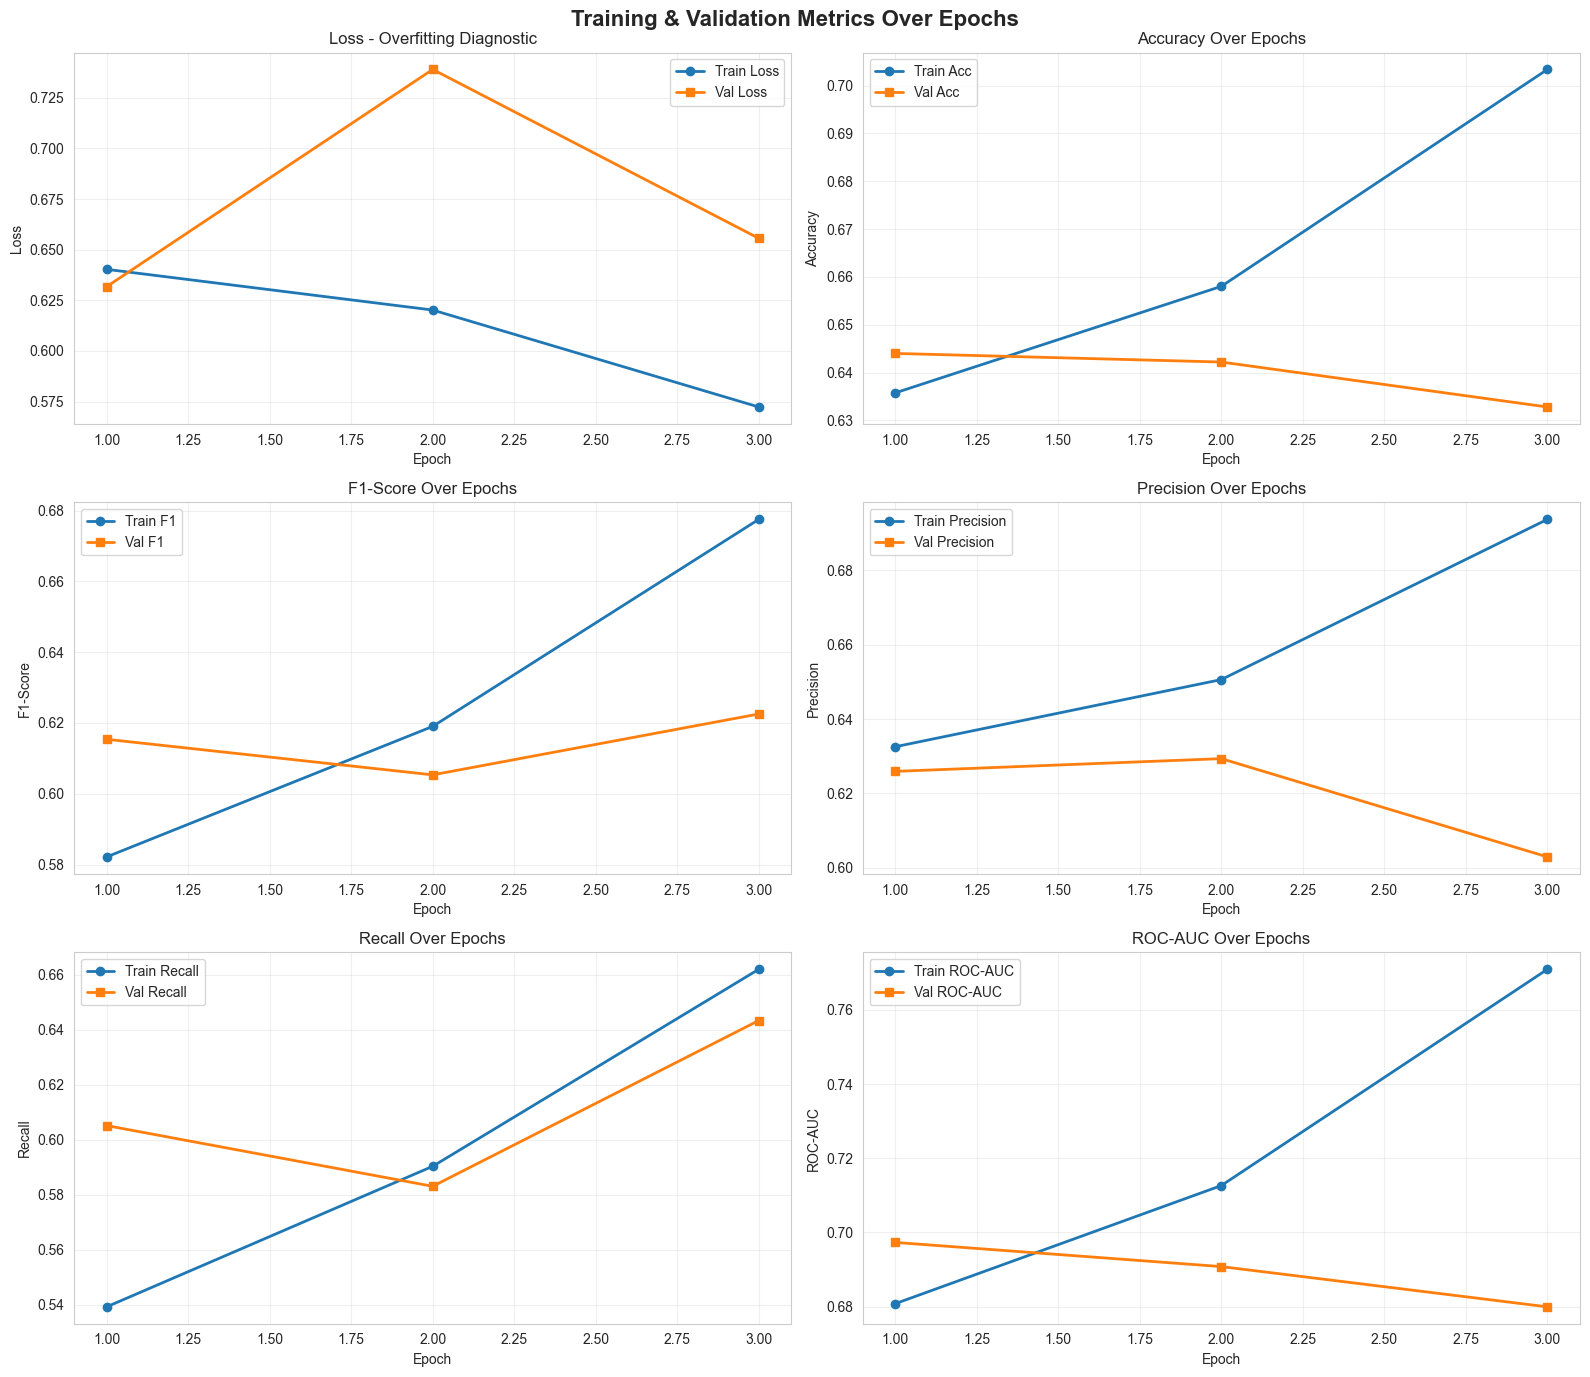

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (16, 12)

# Create subplots for comprehensive training analysis
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('Training & Validation Metrics Over Epochs', fontsize=16, fontweight='bold')

# 1. Loss Curve
axes[0, 0].plot(history["epochs"], history["train_loss"], marker='o', label='Train Loss', linewidth=2)
axes[0, 0].plot(history["epochs"], history["val_loss"], marker='s', label='Val Loss', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss - Overfitting Diagnostic')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 2. Accuracy Curve
axes[0, 1].plot(history["epochs"], history["train_accuracy"], marker='o', label='Train Acc', linewidth=2)
axes[0, 1].plot(history["epochs"], history["val_accuracy"], marker='s', label='Val Acc', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Accuracy Over Epochs')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# 3. F1-Score Curve
axes[1, 0].plot(history["epochs"], history["train_f1"], marker='o', label='Train F1', linewidth=2)
axes[1, 0].plot(history["epochs"], history["val_f1"], marker='s', label='Val F1', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('F1-Score')
axes[1, 0].set_title('F1-Score Over Epochs')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Precision Curve
axes[1, 1].plot(history["epochs"], history["train_precision"], marker='o', label='Train Precision', linewidth=2)
axes[1, 1].plot(history["epochs"], history["val_precision"], marker='s', label='Val Precision', linewidth=2)
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Precision')
axes[1, 1].set_title('Precision Over Epochs')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# 5. Recall Curve
axes[2, 0].plot(history["epochs"], history["train_recall"], marker='o', label='Train Recall', linewidth=2)
axes[2, 0].plot(history["epochs"], history["val_recall"], marker='s', label='Val Recall', linewidth=2)
axes[2, 0].set_xlabel('Epoch')
axes[2, 0].set_ylabel('Recall')
axes[2, 0].set_title('Recall Over Epochs')
axes[2, 0].legend()
axes[2, 0].grid(True, alpha=0.3)

# 6. ROC-AUC Curve
axes[2, 1].plot(history["epochs"], history["train_roc_auc"], marker='o', label='Train ROC-AUC', linewidth=2)
axes[2, 1].plot(history["epochs"], history["val_roc_auc"], marker='s', label='Val ROC-AUC', linewidth=2)
axes[2, 1].set_xlabel('Epoch')
axes[2, 1].set_ylabel('ROC-AUC')
axes[2, 1].set_title('ROC-AUC Over Epochs')
axes[2, 1].legend()
axes[2, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 12. Testing / Final Evaluation

In [28]:
# Check if the file exists before loading
if not os.path.exists(MODEL_SAVE_PATH):
    print(f"Error: Model file not found at {MODEL_SAVE_PATH}")
    print("Please ensure the model was saved correctly during training.")
else:
    model.load_state_dict(torch.load(MODEL_SAVE_PATH))

test_results = evaluate(model, test_loader)
test_acc = test_results["Accuracy"]

print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Accuracy: 0.6522


In [29]:
# ------- OVERFITTING DIAGNOSTICS -------
print("\n" + "="*80)
print("OVERFITTING DIAGNOSTICS")
print("="*80)

train_loss_gap = history["train_loss"][-1] - history["val_loss"][-1]
train_acc_gap = history["train_accuracy"][-1] - history["val_accuracy"][-1]
train_loss_improvement = history["train_loss"][0] - history["train_loss"][-1]
val_loss_improvement = history["val_loss"][0] - history["val_loss"][-1]

print(f"\nFinal Epoch Statistics:")
print(f"  Train Loss: {history['train_loss'][-1]:.4f} → Val Loss: {history['val_loss'][-1]:.4f}")
print(f"  Train Acc:  {history['train_accuracy'][-1]:.4f} → Val Acc:  {history['val_accuracy'][-1]:.4f}")
print(f"  Train F1:   {history['train_f1'][-1]:.4f} → Val F1:   {history['val_f1'][-1]:.4f}")

print(f"\nGap Analysis (Train - Val):")
print(f"  Loss Gap: {train_loss_gap:+.4f}")
print(f"  Acc Gap:  {train_acc_gap:+.4f}")

print(f"\nImprovement from Epoch 1 to Final:")
print(f"  Train Loss: {train_loss_improvement:+.4f}")
print(f"  Val Loss:   {val_loss_improvement:+.4f}")

if train_loss_gap > 0.1 or train_acc_gap > 0.1:
    print(f"\n⚠️  OVERFITTING DETECTED: Large gap between train and validation metrics")
else:
    print(f"\n✅ GOOD GENERALIZATION: Train and validation metrics are well-aligned")


OVERFITTING DIAGNOSTICS

Final Epoch Statistics:
  Train Loss: 0.5723 → Val Loss: 0.6556
  Train Acc:  0.7034 → Val Acc:  0.6328
  Train F1:   0.6775 → Val F1:   0.6225

Gap Analysis (Train - Val):
  Loss Gap: -0.0833
  Acc Gap:  +0.0706

Improvement from Epoch 1 to Final:
  Train Loss: +0.0680
  Val Loss:   -0.0239

✅ GOOD GENERALIZATION: Train and validation metrics are well-aligned


## 12.2 Visualization

In [30]:
all_probs = test_results["probs"]
all_preds = test_results["preds"]
all_targets = test_results["targets"]

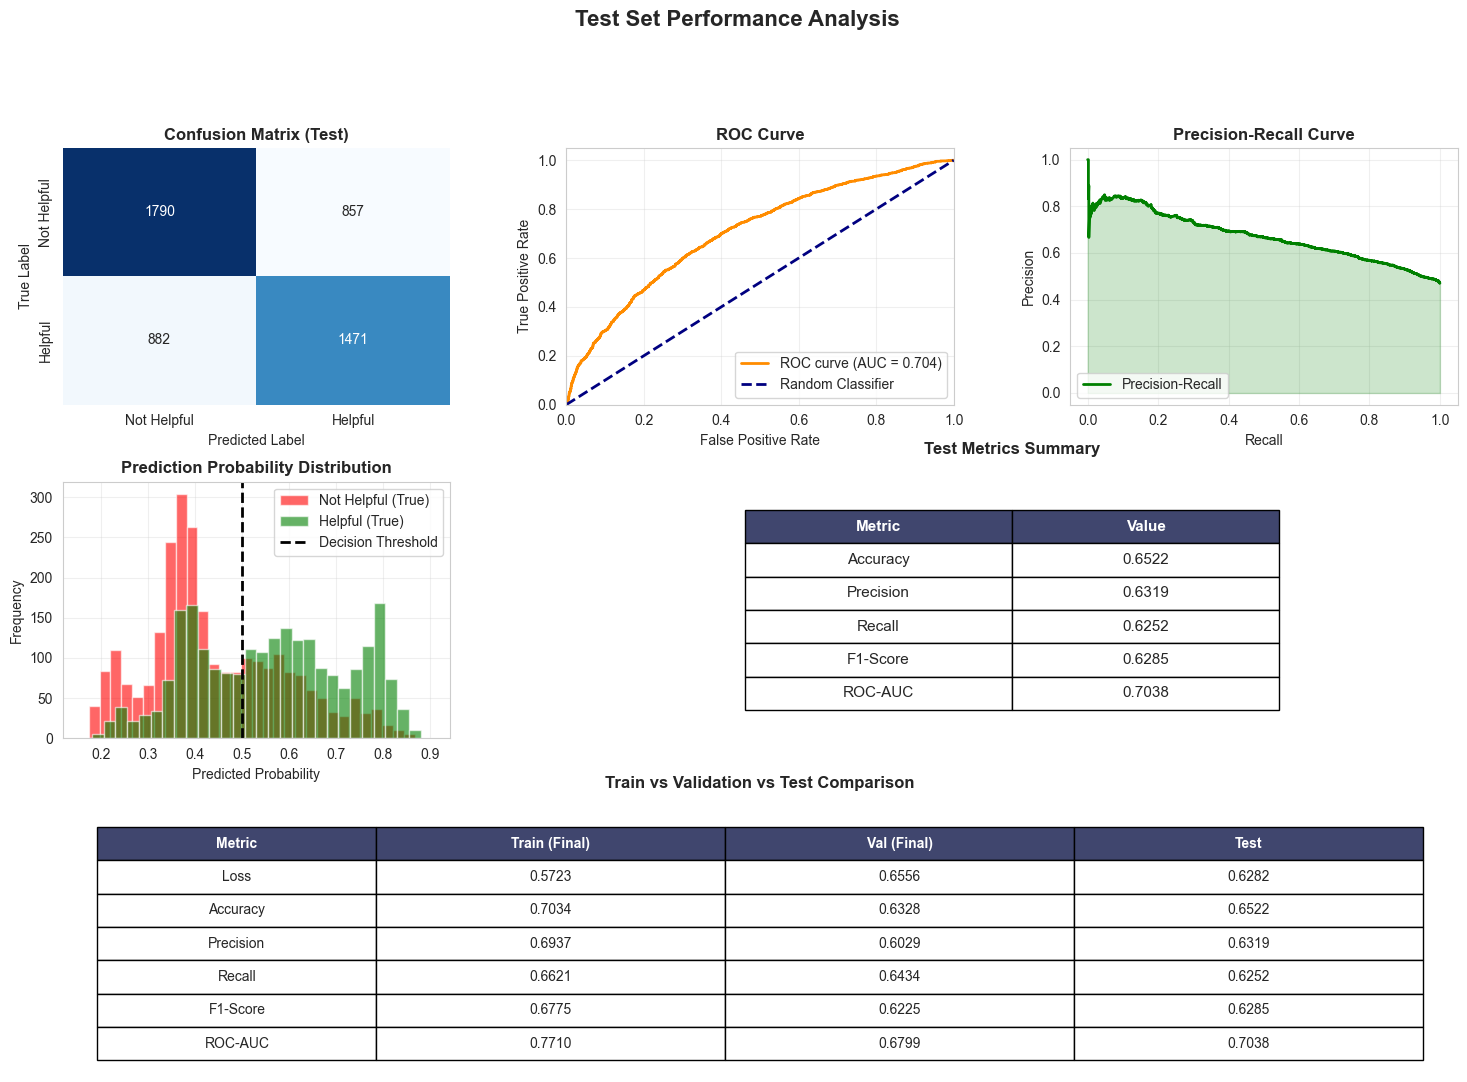

In [31]:
# Create comprehensive visualization
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Confusion Matrix
ax1 = fig.add_subplot(gs[0, 0])
cm = test_results["Confusion Matrix"]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax1, cbar=False)
ax1.set_title('Confusion Matrix (Test)', fontweight='bold')
ax1.set_ylabel('True Label')
ax1.set_xlabel('Predicted Label')
ax1.set_xticklabels(['Not Helpful', 'Helpful'])
ax1.set_yticklabels(['Not Helpful', 'Helpful'])

# 2. ROC Curve
ax2 = fig.add_subplot(gs[0, 1])
fpr, tpr, _ = roc_curve(all_targets, all_probs)
roc_auc = auc(fpr, tpr)
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curve', fontweight='bold')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

# 3. Precision-Recall Curve
ax3 = fig.add_subplot(gs[0, 2])
precision, recall, _ = precision_recall_curve(all_targets, all_probs)
ax3.plot(recall, precision, color='green', lw=2, label='Precision-Recall')
ax3.fill_between(recall, precision, alpha=0.2, color='green')
ax3.set_xlabel('Recall')
ax3.set_ylabel('Precision')
ax3.set_title('Precision-Recall Curve', fontweight='bold')
ax3.legend(loc="lower left")
ax3.grid(True, alpha=0.3)

# 4. Prediction Distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(all_probs[all_targets == 0], bins=30, alpha=0.6, label='Not Helpful (True)', color='red')
ax4.hist(all_probs[all_targets == 1], bins=30, alpha=0.6, label='Helpful (True)', color='green')
ax4.set_xlabel('Predicted Probability')
ax4.set_ylabel('Frequency')
ax4.set_title('Prediction Probability Distribution', fontweight='bold')
ax4.axvline(0.5, color='black', linestyle='--', linewidth=2, label='Decision Threshold')
ax4.legend()
ax4.grid(True, alpha=0.3)

# 5. Metrics Comparison Table
ax5 = fig.add_subplot(gs[1, 1:])
ax5.axis('tight')
ax5.axis('off')

metrics_data = [
    ['Metric', 'Value'],
    ['Accuracy', f"{test_results['Accuracy']:.4f}"],
    ['Precision', f"{test_results['Precision']:.4f}"],
    ['Recall', f"{test_results['Recall']:.4f}"],
    ['F1-Score', f"{test_results['F1-score']:.4f}"],
    ['ROC-AUC', f"{test_results['ROC-AUC']:.4f}"]
]

table = ax5.table(cellText=metrics_data, cellLoc='center', loc='center', 
                  colWidths=[0.3, 0.3])
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1, 2)

# Style header row
for i in range(2):
    table[(0, i)].set_facecolor('#40466e')
    table[(0, i)].set_text_props(weight='bold', color='white')

ax5.set_title('Test Metrics Summary', fontweight='bold', pad=20)

# 6. Train vs Val vs Test Comparison
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('tight')
ax6.axis('off')

comparison_data = [
    ['Metric', 'Train (Final)', 'Val (Final)', 'Test'],
    ['Loss', f"{history['train_loss'][-1]:.4f}", f"{history['val_loss'][-1]:.4f}", 
     f"{test_results['Loss']:.4f}"],
    ['Accuracy', f"{history['train_accuracy'][-1]:.4f}", f"{history['val_accuracy'][-1]:.4f}", 
     f"{test_results['Accuracy']:.4f}"],
    ['Precision', f"{history['train_precision'][-1]:.4f}", f"{history['val_precision'][-1]:.4f}", 
     f"{test_results['Precision']:.4f}"],
    ['Recall', f"{history['train_recall'][-1]:.4f}", f"{history['val_recall'][-1]:.4f}", 
     f"{test_results['Recall']:.4f}"],
    ['F1-Score', f"{history['train_f1'][-1]:.4f}", f"{history['val_f1'][-1]:.4f}", 
     f"{test_results['F1-score']:.4f}"],
    ['ROC-AUC', f"{history['train_roc_auc'][-1]:.4f}", f"{history['val_roc_auc'][-1]:.4f}", 
     f"{test_results['ROC-AUC']:.4f}"]
]

comparison_table = ax6.table(cellText=comparison_data, cellLoc='center', loc='center',
                             colWidths=[0.2, 0.25, 0.25, 0.25])
comparison_table.auto_set_font_size(False)
comparison_table.set_fontsize(10)
comparison_table.scale(1, 2)

# Style header row
for i in range(4):
    comparison_table[(0, i)].set_facecolor('#40466e')
    comparison_table[(0, i)].set_text_props(weight='bold', color='white')

ax6.set_title('Train vs Validation vs Test Comparison', fontweight='bold', pad=20)

plt.suptitle('Test Set Performance Analysis', fontsize=16, fontweight='bold', y=0.995)
plt.show()

# 13. Error Analysis 

In [32]:
# Create comprehensive error analysis by modality
test_df_copy = test_df.reset_index(drop=True).copy()
test_df_copy['predicted_prob'] = all_probs
test_df_copy['predicted_label'] = all_preds
test_df_copy['true_label'] = all_targets
test_df_copy['is_correct'] = (test_df_copy['predicted_label'] == test_df_copy['true_label']).astype(int)


1. TEXT COLUMN (combined_text) ANALYSIS:
----------------------------------------------------------------------------------------------------
Error Rate by Text Length:
  (-0.749, 5.015]: Error Rate = 0.3499 (4964 reviews)
  (5.015, 10.75]: Error Rate = 0.0625 (32 reviews)
  (10.75, 16.485]: Error Rate = 0.0000 (2 reviews)
  (16.485, 22.22]: Error Rate = 0.0000 (1 reviews)
  (22.22, 27.956]: Error Rate = 0.0000 (1 reviews)


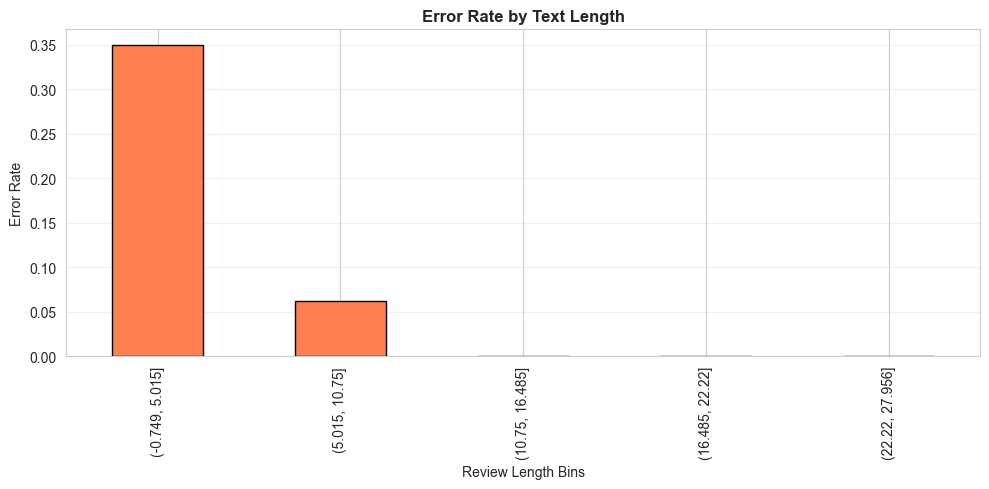

In [33]:
print("\n1. TEXT COLUMN (combined_text) ANALYSIS:")
print("-" * 100)

# Bin by text length (similar to review_length)
text_length_bins = pd.cut(test_df_copy['review_length'], bins=5)
error_by_text = test_df_copy.groupby(text_length_bins)['is_correct'].apply(lambda x: 1 - x.mean())

print("Error Rate by Text Length:")
for bin_range, error_rate in error_by_text.items():
    count = (text_length_bins == bin_range).sum()
    print(f"  {bin_range}: Error Rate = {error_rate:.4f} ({count} reviews)")

# Visualization
fig, ax = plt.subplots(figsize=(10, 5))
error_by_text.plot(kind='bar', ax=ax, color='coral', edgecolor='black')
ax.set_title('Error Rate by Text Length', fontweight='bold', fontsize=12)
ax.set_ylabel('Error Rate')
ax.set_xlabel('Review Length Bins')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()



2. METADATA COLUMNS ANALYSIS:
----------------------------------------------------------------------------------------------------

  rating:
    (-1.656, -1.158]: Error Rate = 0.3542 (1053 reviews)
    (-1.158, -0.662]: Error Rate = 0.3776 (339 reviews)
    (-0.662, -0.167]: Error Rate = 0.3268 (456 reviews)
    (-0.167, 0.329]: Error Rate = 0.3589 (652 reviews)
    (0.329, 0.824]: Error Rate = 0.3420 (2500 reviews)

  review_length:
    (-0.749, 5.015]: Error Rate = 0.3499 (4964 reviews)
    (5.015, 10.75]: Error Rate = 0.0625 (32 reviews)
    (10.75, 16.485]: Error Rate = 0.0000 (2 reviews)
    (16.485, 22.22]: Error Rate = 0.0000 (1 reviews)
    (22.22, 27.956]: Error Rate = 0.0000 (1 reviews)

  chars_per_word:
    (-2.064, 0.923]: Error Rate = 0.3535 (4481 reviews)
    (0.923, 3.895]: Error Rate = 0.3010 (495 reviews)
    (3.895, 6.867]: Error Rate = 0.2500 (20 reviews)
    (6.867, 9.839]: Error Rate = 0.3333 (3 reviews)
    (9.839, 12.81]: Error Rate = 0.0000 (1 reviews)

  ima

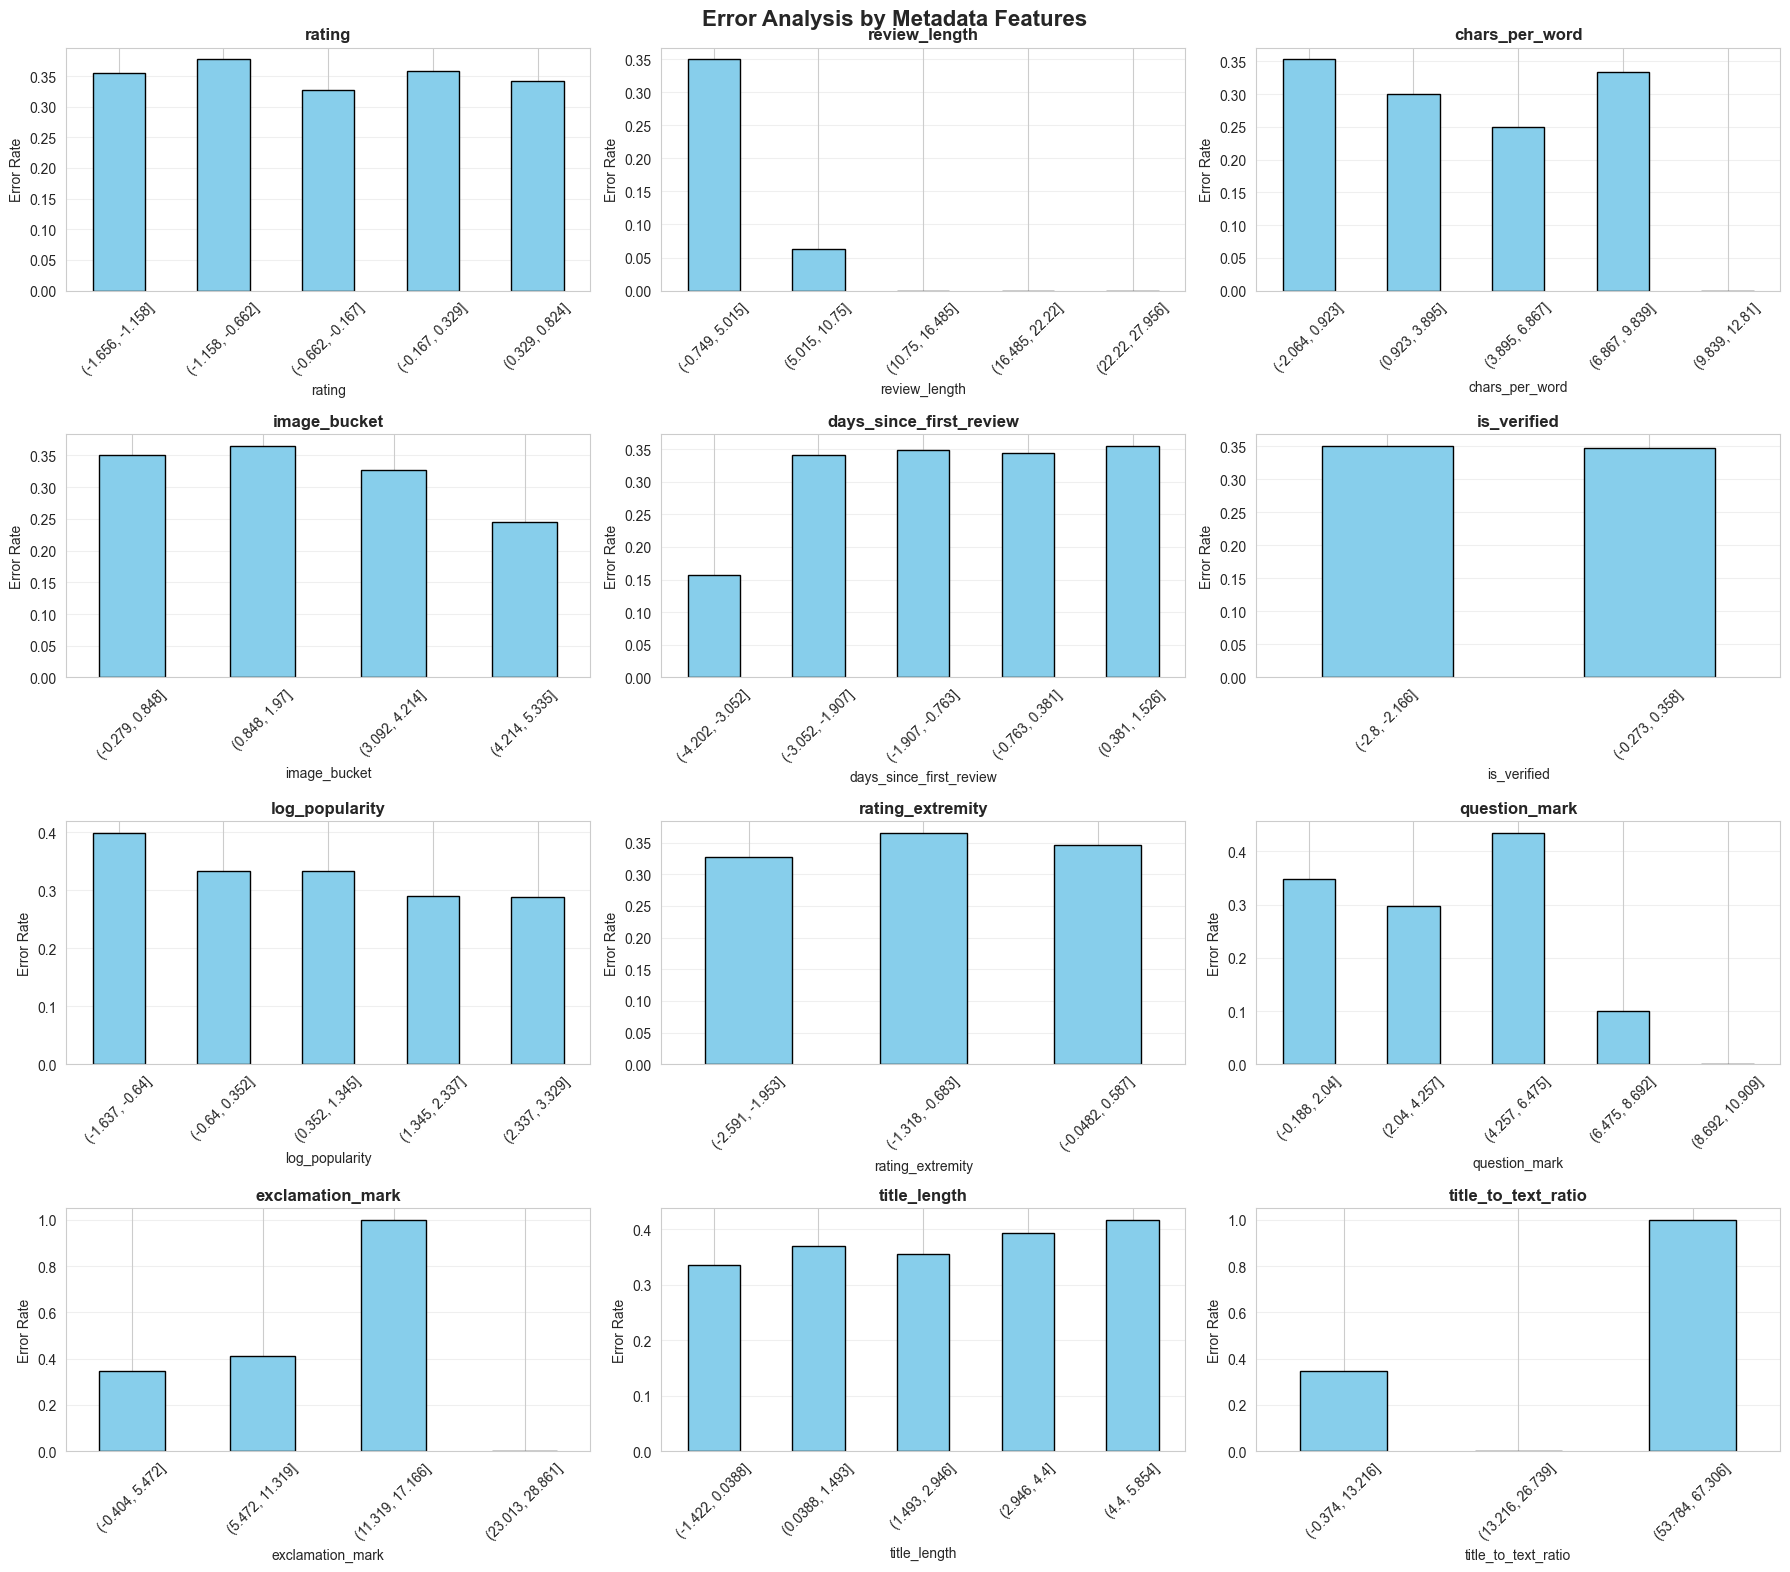

In [34]:
print("\n2. METADATA COLUMNS ANALYSIS:")
print("-" * 100)

# Analyze each metadata feature
metadata_error_analysis = {}

for col in METADATA_COLUMNS:
    if col in test_df_copy.columns:
        # Create bins for continuous features (5 bins)
        if test_df_copy[col].dtype in ['float64', 'float32', 'int64', 'int32']:
            bins = pd.cut(test_df_copy[col], bins=5)
            error_rates = test_df_copy.groupby(bins)['is_correct'].apply(lambda x: 1 - x.mean())
            metadata_error_analysis[col] = error_rates
            
            print(f"\n  {col}:")
            for bin_range, error_rate in error_rates.items():
                count = (bins == bin_range).sum()
                print(f"    {bin_range}: Error Rate = {error_rate:.4f} ({count} reviews)")

# Visualization: Error rate by metadata features
fig, axes = plt.subplots(4, 3, figsize=(18, 16))
axes = axes.flatten()
fig.suptitle('Error Analysis by Metadata Features', fontsize=16, fontweight='bold')

for idx, (col, error_rates) in enumerate(metadata_error_analysis.items()):
    if idx < len(axes):
        error_rates.plot(kind='bar', ax=axes[idx], color='skyblue', edgecolor='black')
        axes[idx].set_title(f'{col}', fontweight='bold')
        axes[idx].set_ylabel('Error Rate')
        axes[idx].grid(True, alpha=0.3, axis='y')
        axes[idx].tick_params(axis='x', rotation=45)

# Hide unused subplots
for idx in range(len(metadata_error_analysis), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.show()


3. IMAGE COLUMN (image_path) ANALYSIS:
----------------------------------------------------------------------------------------------------

3. IMAGE COLUMN (image_path) ANALYSIS:
----------------------------------------------------------------------------------------------------
Error Rate by Image Availability:
  No Image: Error Rate = 0.3497 (4561 reviews)
  Has Image: Error Rate = 0.3280 (439 reviews)

Error Rate by Image Bucket:
  -0.2733806834163279: Error Rate = 0.3499 (4558 reviews)
  1.5962085346813153: Error Rate = 0.3648 (233 reviews)
  3.4657977527789585: Error Rate = 0.3263 (95 reviews)
  5.335386970876602: Error Rate = 0.2456 (114 reviews)


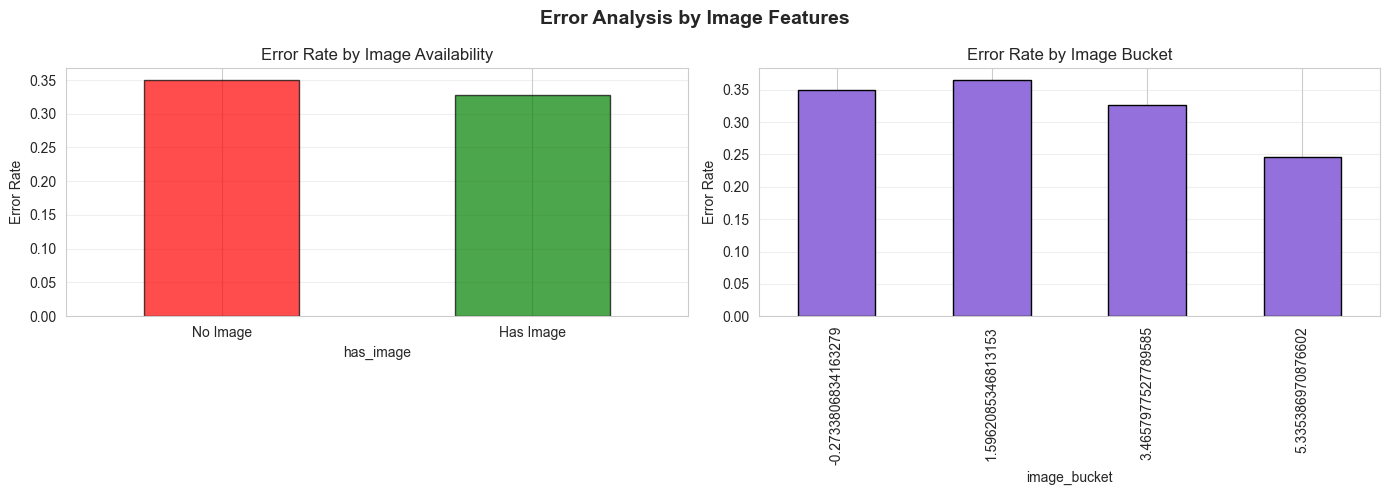

In [35]:
print("\n3. IMAGE COLUMN (image_path) ANALYSIS:")
print("-" * 100)

# Error by image availability
print("\n3. IMAGE COLUMN (image_path) ANALYSIS:")
print("-" * 100)

# Create has_image column
test_df_copy['has_image'] = test_df_copy[IMAGE_PATH_COLUMN].notna().astype(int)

# Error by image availability
error_by_image = test_df_copy.groupby('has_image')['is_correct'].apply(lambda x: 1 - x.mean())
image_labels = ['No Image', 'Has Image']

print("Error Rate by Image Availability:")
for idx, (has_img, error_rate) in enumerate(error_by_image.items()):
    count = (test_df_copy['has_image'] == has_img).sum()
    label = image_labels[idx] if idx < len(image_labels) else f"Value {has_img}"
    print(f"  {label}: Error Rate = {error_rate:.4f} ({count} reviews)")

# Error by image bucket!
error_by_image_bucket = test_df_copy.groupby('image_bucket')['is_correct'].apply(lambda x: 1 - x.mean())

print("\nError Rate by Image Bucket:")
for bucket, error_rate in error_by_image_bucket.items():
    count = (test_df_copy['image_bucket'] == bucket).sum()
    print(f"  {bucket}: Error Rate = {error_rate:.4f} ({count} reviews)")


# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Error Analysis by Image Features', fontsize=14, fontweight='bold')

# Image availability
error_by_image.plot(kind='bar', ax=axes[0], color=['red', 'green'], alpha=0.7, edgecolor='black')
axes[0].set_title('Error Rate by Image Availability')
axes[0].set_ylabel('Error Rate')
axes[0].set_xticklabels(image_labels, rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Image bucket
error_by_image_bucket.plot(kind='bar', ax=axes[1], color='mediumpurple', edgecolor='black')
axes[1].set_title('Error Rate by Image Bucket')
axes[1].set_ylabel('Error Rate')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [36]:
print("\n" + "=" * 100)
print("SUMMARY: WORST & BEST PERFORMING CATEGORIES")
print("=" * 100)

print("\nTEXT FEATURES:")
print(f"  Worst: {error_by_text.idxmax()} (Error: {error_by_text.max():.4f})")
print(f"  Best:  {error_by_text.idxmin()} (Error: {error_by_text.min():.4f})")

print("\nMETADATA FEATURES (Overall error rates per feature):")
for col, error_rates in metadata_error_analysis.items():
    print(f"  {col}: Min={error_rates.min():.4f}, Max={error_rates.max():.4f}, Mean={error_rates.mean():.4f}")

print("\nIMAGE FEATURES:")
print(f"  By Availability - Worst: {'Has Image' if error_by_image.idxmax() == 1 else 'No Image'} (Error: {error_by_image.max():.4f})")
print(f"  By Availability - Best:  {'Has Image' if error_by_image.idxmin() == 1 else 'No Image'} (Error: {error_by_image.min():.4f})")
print(f"  By Bucket - Worst: {error_by_image_bucket.idxmax()} (Error: {error_by_image_bucket.max():.4f})")
print(f"  By Bucket - Best:  {error_by_image_bucket.idxmin()} (Error: {error_by_image_bucket.min():.4f})")


SUMMARY: WORST & BEST PERFORMING CATEGORIES

TEXT FEATURES:
  Worst: (-0.749, 5.015] (Error: 0.3499)
  Best:  (10.75, 16.485] (Error: 0.0000)

METADATA FEATURES (Overall error rates per feature):
  rating: Min=0.3268, Max=0.3776, Mean=0.3519
  review_length: Min=0.0000, Max=0.3499, Mean=0.0825
  chars_per_word: Min=0.0000, Max=0.3535, Mean=0.2476
  image_bucket: Min=0.2456, Max=0.3648, Mean=0.3217
  days_since_first_review: Min=0.1562, Max=0.3546, Mean=0.3088
  is_verified: Min=0.3475, Max=0.3501, Mean=0.3488
  log_popularity: Min=0.2895, Max=0.3993, Mean=0.3292
  rating_extremity: Min=0.3268, Max=0.3653, Mean=0.3459
  question_mark: Min=0.0000, Max=0.4348, Mean=0.2362
  exclamation_mark: Min=0.0000, Max=1.0000, Mean=0.4398
  title_length: Min=0.3349, Max=0.4167, Mean=0.3737
  title_to_text_ratio: Min=0.0000, Max=1.0000, Mean=0.4492

IMAGE FEATURES:
  By Availability - Worst: No Image (Error: 0.3497)
  By Availability - Best:  Has Image (Error: 0.3280)
  By Bucket - Worst: 1.596208534

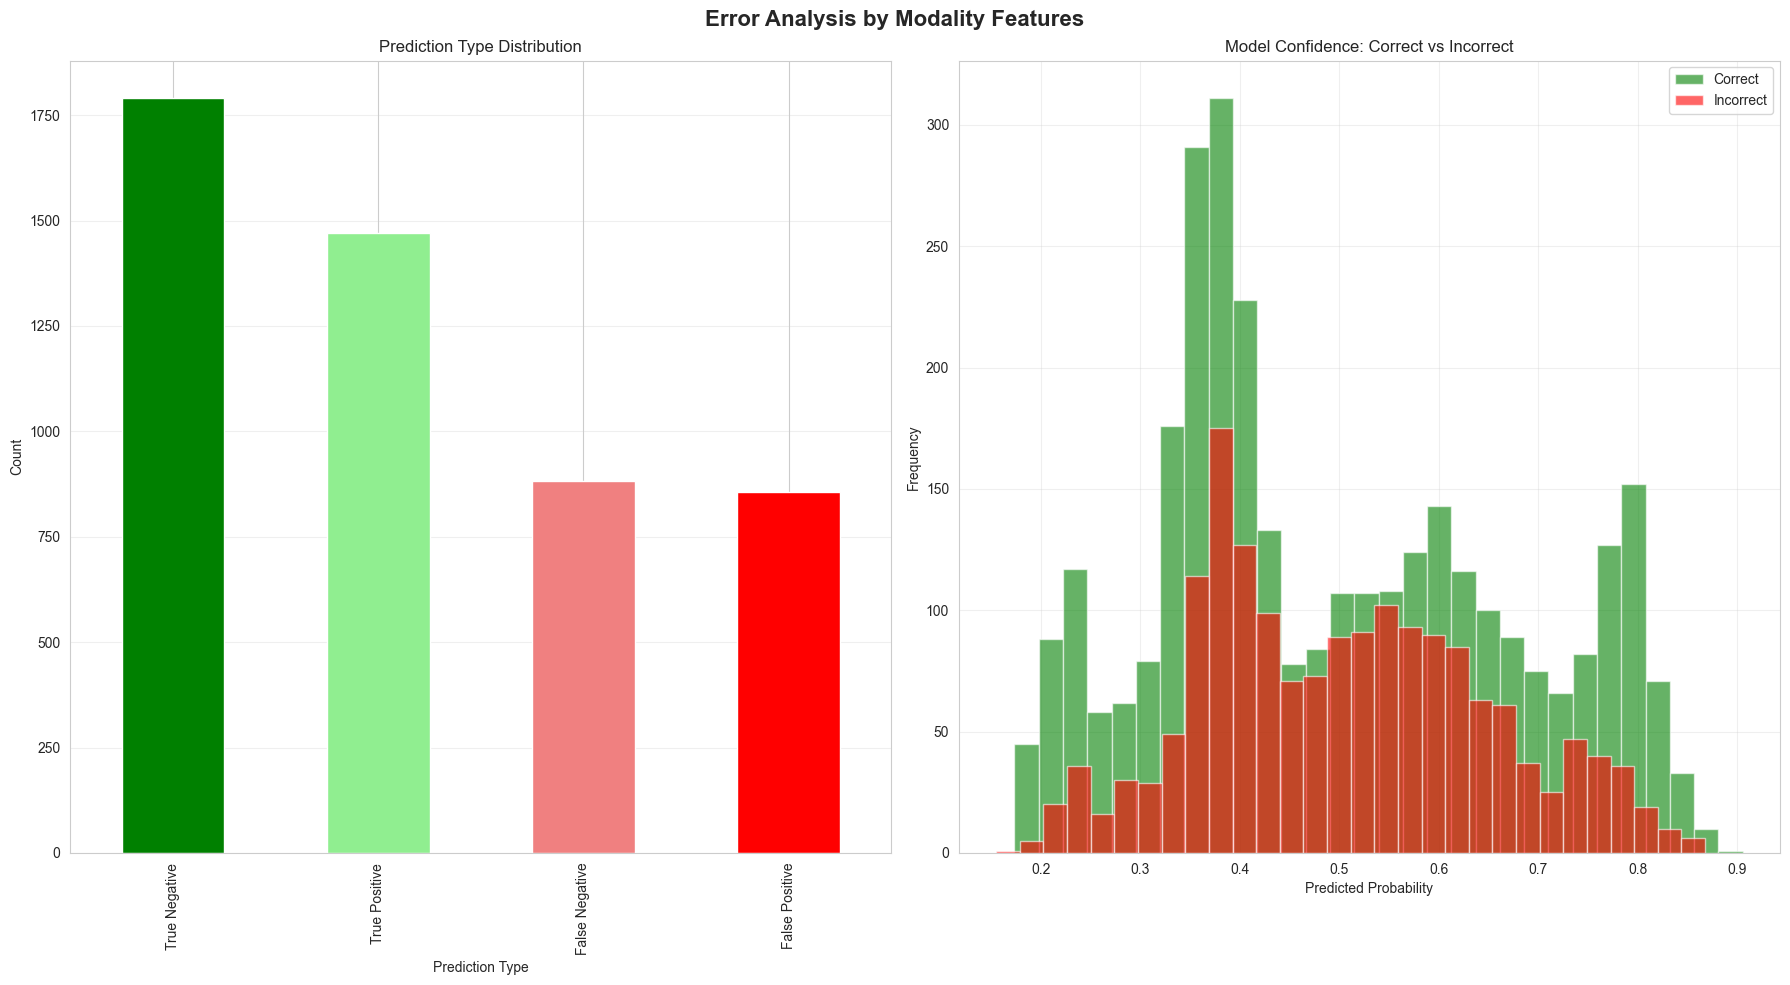

In [ ]:
# Create visualization for error analysis
fig, axes = plt.subplots(1, 2, figsize=(18, 10))
fig.suptitle('Error Analysis by Modality Features', fontsize=16, fontweight='bold')

# 1. Error distribution by type
ax = axes[0]  # Changed from axes[0, 0]
error_counts = test_df_copy['error_type'].value_counts()
colors = ['green', 'lightgreen', 'lightcoral', 'red']
error_counts.plot(kind='bar', ax=ax, color=colors)
ax.set_title('Prediction Type Distribution')
ax.set_ylabel('Count')
ax.set_xlabel('Prediction Type')
ax.grid(True, alpha=0.3, axis='y')

# 2. Confidence by correctness
ax = axes[1]  # Changed from axes[1, 0]
correct_probs = test_df_copy[test_df_copy['is_correct'] == 1]['predicted_prob']
incorrect_probs = test_df_copy[test_df_copy['is_correct'] == 0]['predicted_prob']
ax.hist(correct_probs, bins=30, alpha=0.6, label='Correct', color='green')
ax.hist(incorrect_probs, bins=30, alpha=0.6, label='Incorrect', color='red')
ax.set_xlabel('Predicted Probability')
ax.set_ylabel('Frequency')
ax.set_title('Model Confidence: Correct vs Incorrect')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [39]:
print(f"\nMODEL CONFIDENCE ANALYSIS:")
print(f"  Mean confidence on correct predictions: {correct_probs.mean():.4f}")
print(f"  Mean confidence on incorrect predictions: {incorrect_probs.mean():.4f}")


MODEL CONFIDENCE ANALYSIS:
  Mean confidence on correct predictions: 0.4960
  Mean confidence on incorrect predictions: 0.5024


# 14 Explainability

In [40]:
import shap
import lime
import lime.lime_text
import lime.lime_tabular
import cv2
from scipy.special import softmax

print("=" * 100)
print("MODEL EXPLAINABILITY: SHAP, LIME, and GRAD-CAM")
print("=" * 100)

MODEL EXPLAINABILITY: SHAP, LIME, and GRAD-CAM



A. LIME Explanation for Text:
Sample Text: Nice small dual battery charger for Lithium Ion SJCAM [SEP] Nice little battery charger, not big and bulky like some.  This is not much bigger than a match box.  Its design, however, allows for two ba...
True Label: Helpful

LIME Top Contributing Words:
  picture              +0.0291  ↑ Helpful
  allows               +0.0262  ↑ Helpful
  SEP                  -0.0232  ↓ Not Helpful
  so                   +0.0216  ↑ Helpful
  The                  +0.0212  ↑ Helpful
  single               +0.0195  ↑ Helpful
  at                   +0.0076  ↑ Helpful
  to                   +0.0074  ↑ Helpful
  wall                 +0.0049  ↑ Helpful
  for                  +0.0038  ↑ Helpful


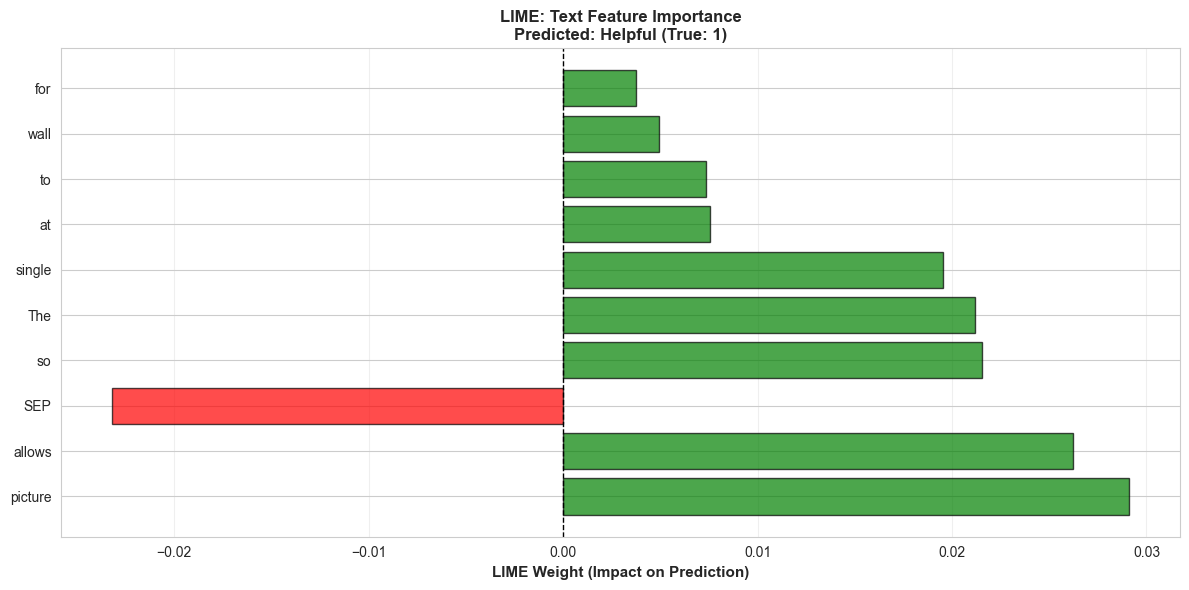



B. SHAP Explanation for Text (using kernel explainer):
(Simplified SHAP: Using token importance)
Sample tokenized text: ['[CLS]', 'nice', 'small', 'dual', 'battery', 'charge', '##r', 'for', 'lithium', 'ion', 's', '##j', '##cam', '[SEP]', 'nice', 'little', 'battery', 'charge', '##r', ',']


In [41]:
class TextModelWrapper:
    """Wrapper to make text predictions compatible with SHAP/LIME"""
    def __init__(self, model, tokenizer, device, max_length=MAX_TEXT_LENGTH):
        self.model = model
        self.tokenizer = tokenizer
        self.device = device
        self.max_length = max_length
    
    def predict_text_only(self, texts):
        """Predict using only text (average probability across modalities)"""
        probs = []
        self.model.eval()
        
        with torch.no_grad():
            for text in texts:
                encoding = self.tokenizer(
                    text,
                    padding="max_length",
                    truncation=True,
                    max_length=self.max_length,
                    return_tensors="pt"
                )
                input_ids = encoding["input_ids"].to(self.device)
                attention_mask = encoding["attention_mask"].to(self.device)
                
                # Dummy image and metadata (neutral values)
                image = torch.zeros(1, 3, 224, 224).to(self.device)
                metadata = torch.zeros(1, 12).to(self.device)  # 12 metadata features
                
                output = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    image=image,
                    metadata=metadata
                )
                prob = torch.sigmoid(output).cpu().numpy()[0]
                probs.append([1 - prob, prob])
        
        return np.array(probs)

# Create wrapper
text_wrapper = TextModelWrapper(model, tokenizer, device)

# ---- LIME EXPLANATION FOR TEXT ----
print("\nA. LIME Explanation for Text:")

# Select a sample review
sample_idx = 0
sample_text = test_df.iloc[sample_idx][TEXT_COLUMN]
true_label = test_df.iloc[sample_idx][LABEL_COLUMN]

print(f"Sample Text: {sample_text[:200]}...")
print(f"True Label: {'Helpful' if true_label == 1 else 'Not Helpful'}")

# Create LIME explainer
explainer_lime = lime.lime_text.LimeTextExplainer(
    class_names=['Not Helpful', 'Helpful'],
    verbose=False
)

# Get explanation
explanation_lime = explainer_lime.explain_instance(
    sample_text,
    text_wrapper.predict_text_only,
    num_features=10,
    num_samples=100
)

print(f"\nLIME Top Contributing Words:")
for word, weight in explanation_lime.as_list():
    sentiment = "↑ Helpful" if weight > 0 else "↓ Not Helpful"
    print(f"  {word:20s} {weight:+.4f}  {sentiment}")

# Visualize LIME explanation
fig, ax = plt.subplots(figsize=(12, 6))
weights = [weight for _, weight in explanation_lime.as_list()]
words = [word for word, _ in explanation_lime.as_list()]
colors = ['green' if w > 0 else 'red' for w in weights]

bars = ax.barh(range(len(words)), weights, color=colors, alpha=0.7, edgecolor='black')
ax.set_yticks(range(len(words)))
ax.set_yticklabels(words, fontsize=10)
ax.set_xlabel('LIME Weight (Impact on Prediction)', fontsize=11, fontweight='bold')
ax.set_title(f'LIME: Text Feature Importance\nPredicted: Helpful (True: {true_label})', 
             fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

# ---- SHAP EXPLANATION FOR TEXT ----
print("\n\nB. SHAP Explanation for Text (using kernel explainer):")

# Sample texts for SHAP background
background_texts = test_df.iloc[:50][TEXT_COLUMN].values

# Create SHAP explainer (kernel explainer for model-agnostic approach)
# Note: This is computationally expensive, so we use fewer background samples
def shap_predict_wrapper(texts):
    """Convert texts to predictions for SHAP"""
    return text_wrapper.predict_text_only(texts)[:, 1]  # Return probability of helpful

# For efficiency, we'll use a simpler approach: feature-based SHAP on tokenized text
print("(Simplified SHAP: Using token importance)")

sample_encoding = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=MAX_TEXT_LENGTH,
    return_tensors="pt"
)
sample_tokens = tokenizer.convert_ids_to_tokens(sample_encoding['input_ids'][0])
sample_tokens = [t for t in sample_tokens if t != '[PAD]']

print(f"Sample tokenized text: {sample_tokens[:20]}")



Sample Metadata (Scaled):
  rating                   : -2.1461
  review_length            : -0.7329
  chars_per_word           : -9.0012
  image_bucket             : -0.7845
  days_since_first_review  : -5.2350
  is_verified              : -1.6694
  log_popularity           : -2.7962
  rating_extremity         : -4.1760
  question_mark            : -0.5046
  exclamation_mark         : -0.5747
  title_length             : -1.4052
  title_to_text_ratio      : -0.5900

SHAP Values (Impact on Helpful Prediction):
  rating                   : +0.023225  ↑ Helpful
  review_length            : +0.000000  ↓ Not Helpful
  chars_per_word           : +0.027353  ↑ Helpful
  image_bucket             : +0.000000  ↓ Not Helpful
  days_since_first_review  : +0.055816  ↑ Helpful
  is_verified              : +0.003994  ↑ Helpful
  log_popularity           : +0.039907  ↑ Helpful
  rating_extremity         : -0.017791  ↓ Not Helpful
  question_mark            : +0.000254  ↑ Helpful
  exclamation_mark     

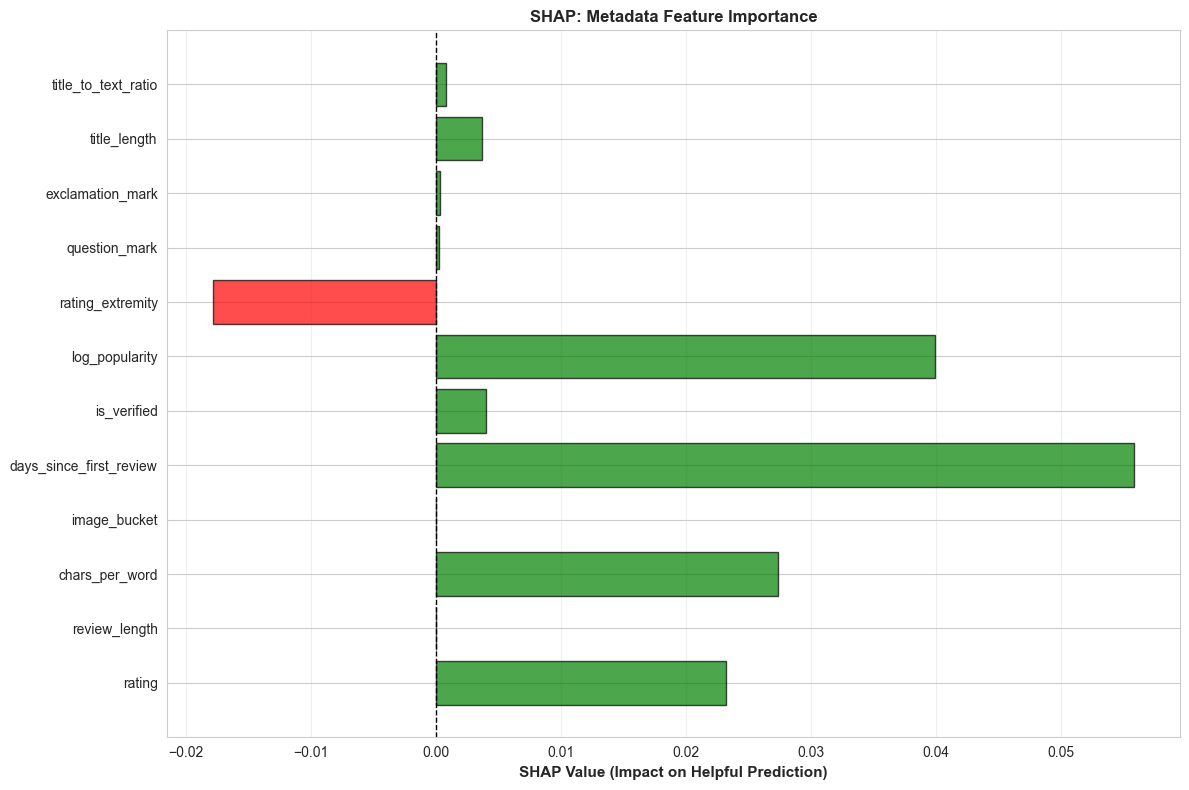

In [43]:
class MetadataModelWrapper:
    """Wrapper to make metadata predictions compatible with SHAP"""
    def __init__(self, model, device, scaler):
        self.model = model
        self.device = device
        self.scaler = scaler
    
    def predict_metadata_only(self, metadata_values):
        """Predict using only metadata (average probability across modalities)"""
        probs = []
        self.model.eval()
        
        with torch.no_grad():
            for row in metadata_values:
                # Dummy text and image
                input_ids = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(self.device)
                attention_mask = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(self.device)
                image = torch.zeros(1, 3, 224, 224).to(self.device)
                
                metadata = torch.tensor(row.astype(np.float32)).unsqueeze(0).to(self.device)
                
                output = self.model(
                    input_ids=input_ids,
                    attention_mask=attention_mask,
                    image=image,
                    metadata=metadata
                )
                prob = torch.sigmoid(output).cpu().numpy()[0]
                probs.append(prob)
        
        return np.array(probs)

# Create wrapper
metadata_wrapper = MetadataModelWrapper(model, device, scaler)

# Get sample metadata
sample_metadata_idx = 0
sample_metadata = test_df.iloc[sample_metadata_idx][METADATA_COLUMNS].values.reshape(1, -1)
sample_metadata_df = pd.DataFrame(sample_metadata, columns=METADATA_COLUMNS)
sample_metadata_scaled = scaler.transform(sample_metadata_df)[0]

print(f"Sample Metadata (Scaled):")
for col, val in zip(METADATA_COLUMNS, sample_metadata_scaled):
    print(f"  {col:25s}: {val:+.4f}")

# Create SHAP explainer for metadata
explainer_shap = shap.KernelExplainer(
    metadata_wrapper.predict_metadata_only,
    shap.sample(test_df[METADATA_COLUMNS].values, min(30, len(test_df)))  # Reduced from 100 to 30
)

# Get SHAP values for sample
shap_values = explainer_shap.shap_values(sample_metadata_scaled)

print(f"\nSHAP Values (Impact on Helpful Prediction):")
for col, val in zip(METADATA_COLUMNS, shap_values):
    sentiment = "↑ Helpful" if val > 0 else "↓ Not Helpful"
    print(f"  {col:25s}: {val:+.6f}  {sentiment}")

# Visualize SHAP explanation
fig, ax = plt.subplots(figsize=(12, 8))

colors = ['green' if v > 0 else 'red' for v in shap_values]
bars = ax.barh(range(len(METADATA_COLUMNS)), shap_values, color=colors, alpha=0.7, edgecolor='black')

ax.set_yticks(range(len(METADATA_COLUMNS)))
ax.set_yticklabels(METADATA_COLUMNS, fontsize=10)
ax.set_xlabel('SHAP Value (Impact on Helpful Prediction)', fontsize=11, fontweight='bold')
ax.set_title('SHAP: Metadata Feature Importance', fontsize=12, fontweight='bold')
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()



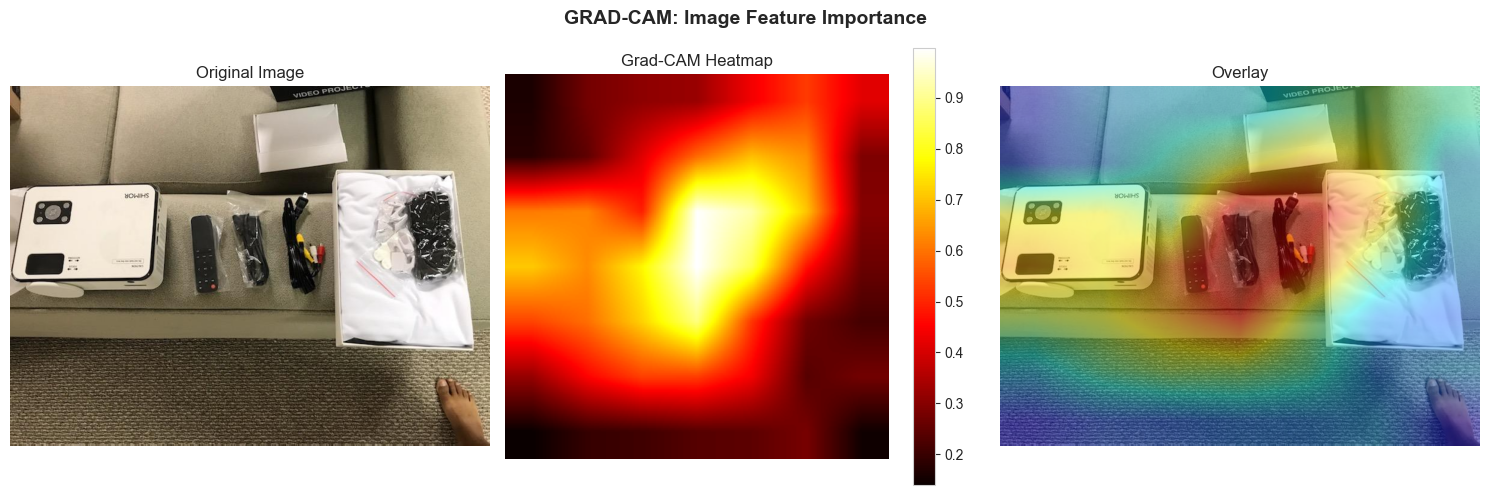

Grad-CAM generated for image: ../data\images\827082.jpg
  Heatmap shows regions important for model prediction
  Red regions: High importance, Green regions: Low importance


In [52]:
class GradCAM:
    """Grad-CAM implementation for image feature importance"""
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        
        # Register hooks
        target_layer.register_forward_hook(self.save_activations)
        target_layer.register_full_backward_hook(self.save_gradients)
    
    def save_activations(self, module, input, output):
        self.activations = output.detach()
    
    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()
    
    def generate_cam(self, input_tensor):
        """Generate Class Activation Map"""
        # Forward pass
        output = self.model(
            input_ids=input_tensor['input_ids'],
            attention_mask=input_tensor['attention_mask'],
            image=input_tensor['image'],
            metadata=input_tensor['metadata']
        )
        
        # Backward pass
        self.model.zero_grad()
        output.backward()
        
        # Handle both 3D and 4D gradient/activation arrays
        gradients = self.gradients.cpu().data.numpy()
        activations = self.activations.cpu().data.numpy()
        
        # If 4D (batch, channels, height, width), take first batch
        if gradients.ndim == 4:
            gradients = gradients[0]
            activations = activations[0]
        
        # Now gradients/activations should be [C, H, W]
        if gradients.ndim != 3:
            print(f"Warning: Unexpected gradient shape {gradients.shape}, skipping CAM")
            return np.zeros((224, 224))
        
        # Weight gradients by average gradient
        weights = np.mean(gradients, axis=(1, 2))  # [C]
        
        # Compute weighted sum
        cam = np.zeros(activations.shape[1:])  # [H, W]
        for i, w in enumerate(weights):
            cam += w * activations[i, :, :]
        
        # Apply ReLU
        cam = np.maximum(cam, 0)
        
        # Normalize
        cam = cam / (cam.max() + 1e-8)
        
        return cam

# Get sample image - find first valid one
sample_image_idx = None
sample_image_path = None

for idx in range(len(test_df)):
    path = test_df.iloc[idx][IMAGE_PATH_COLUMN]
    if pd.notna(path) and isinstance(path, str):
        sample_image_idx = idx
        sample_image_path = path
        break

if sample_image_idx is not None and sample_image_path is not None:
    full_image_path = sample_image_path
    
    if os.path.exists(full_image_path):
        # Load and process image
        sample_image = Image.open(full_image_path).convert("RGB")
        sample_image_tensor = image_transform(sample_image).unsqueeze(0).to(device)
        
        # Dummy text and metadata
        sample_input_ids = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(device)
        sample_attention_mask = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(device)
        sample_metadata = torch.zeros(1, 12).to(device)
        
        input_dict = {
            'input_ids': sample_input_ids,
            'attention_mask': sample_attention_mask,
            'image': sample_image_tensor,
            'metadata': sample_metadata
        }
        
        # Create Grad-CAM - hook into features layer for spatial dimensions
        grad_cam = GradCAM(model, model.image_encoder.features[-1])
        cam = grad_cam.generate_cam(input_dict)
        
        # Resize CAM to original image size
        cam_resized = cv2.resize(cam, (224, 224))
        
        # Create visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        fig.suptitle('GRAD-CAM: Image Feature Importance', fontsize=14, fontweight='bold')
        
        # Original image
        img_array = np.array(sample_image)
        axes[0].imshow(img_array)
        axes[0].set_title('Original Image')
        axes[0].axis('off')
        
        # CAM heatmap
        im = axes[1].imshow(cam_resized, cmap='hot')
        axes[1].set_title('Grad-CAM Heatmap')
        axes[1].axis('off')
        plt.colorbar(im, ax=axes[1])
        
        # Overlay - ensure CAM matches original image dimensions
        cam_resized = cv2.resize(cam, (img_array.shape[1], img_array.shape[0]))  # (width, height)
        overlay = cv2.applyColorMap((cam_resized * 255).astype(np.uint8), cv2.COLORMAP_JET)
        overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
        blended = cv2.addWeighted(img_array, 0.6, overlay, 0.4, 0)
        
        axes[2].imshow(blended)
        axes[2].set_title('Overlay')
        axes[2].axis('off')
        
        plt.tight_layout()
        plt.show()
        
        print(f"Grad-CAM generated for image: {sample_image_path}")
        print(f"  Heatmap shows regions important for model prediction")
        print(f"  Red regions: High importance, Green regions: Low importance")
    else:
        print(f"Warning: Full image path not found: {full_image_path}")
        print("Skipping Grad-CAM visualization")
else:
    print("Warning: No images found in test set")
    print("Skipping Grad-CAM visualization")

sys:1: UserWarning: Full backward hook is firing when gradients are computed with respect to module outputs since no inputs require gradients. See https://docs.pytorch.org/docs/main/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook for more details.


✅ Image loaded: ../data\images\827082.jpg


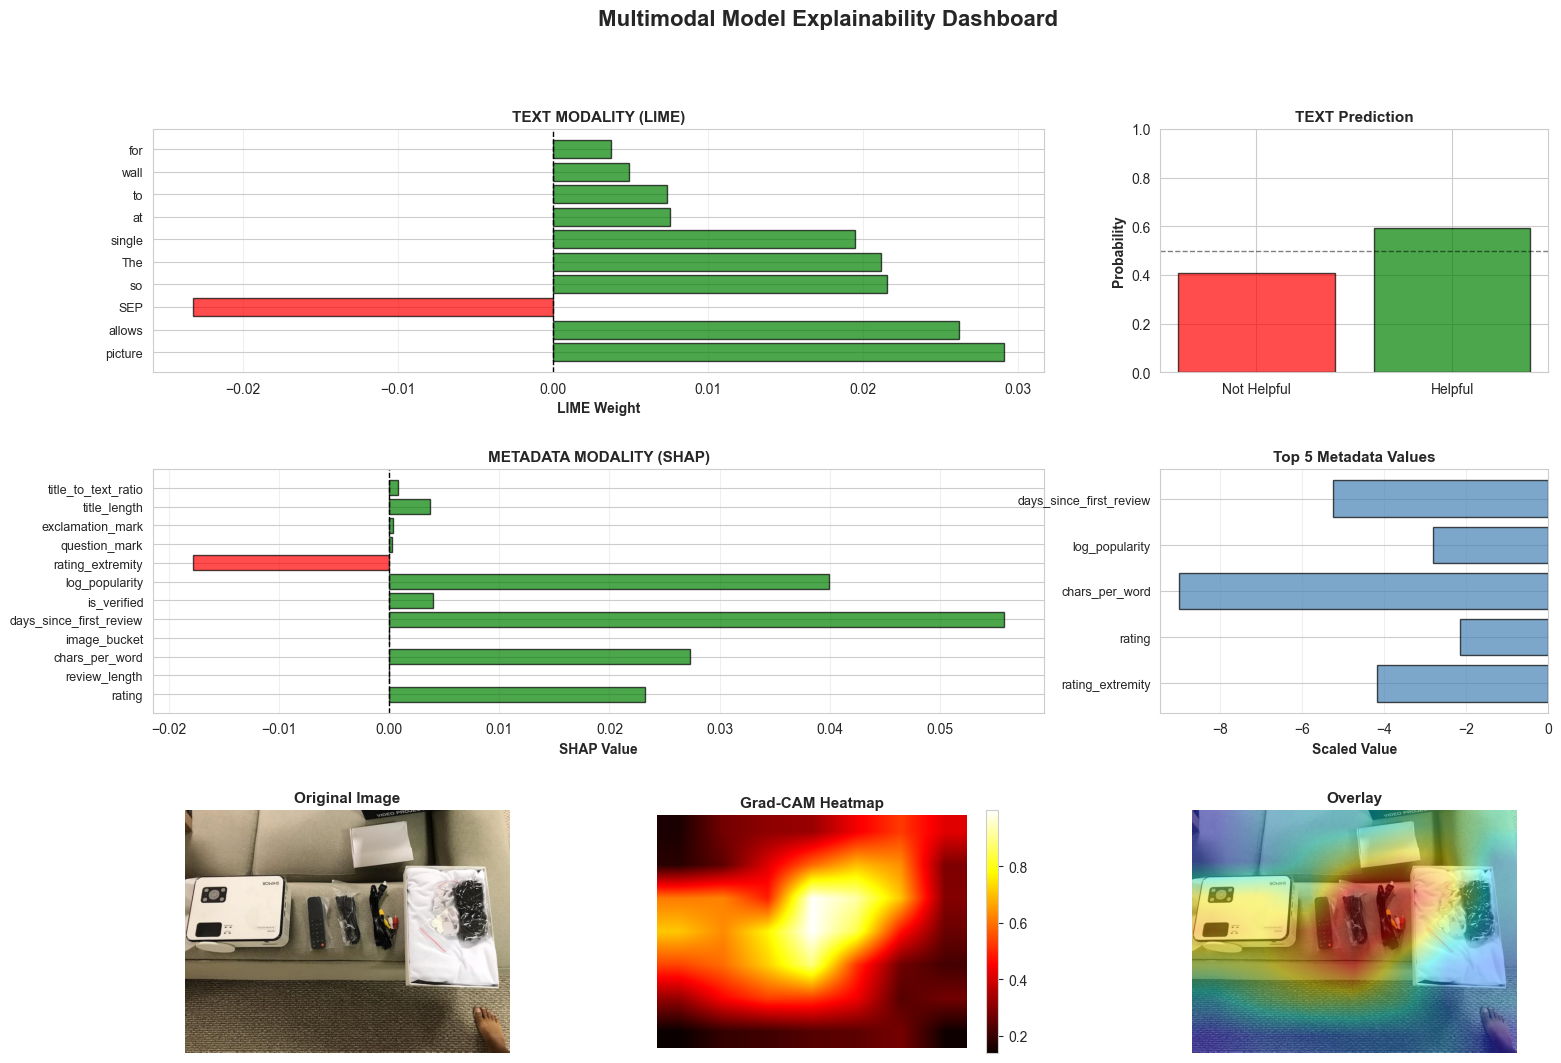


Explainability Dashboard Complete!


In [55]:
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 3, hspace=0.4, wspace=0.3)

# Title
fig.suptitle('Multimodal Model Explainability Dashboard', fontsize=16, fontweight='bold')

# ---- TEXT IMPORTANCE ----
ax1 = fig.add_subplot(gs[0, 0:2])
lime_words = [word for word, _ in explanation_lime.as_list()]
lime_weights = [weight for _, weight in explanation_lime.as_list()]
colors_text = ['green' if w > 0 else 'red' for w in lime_weights]
ax1.barh(range(len(lime_words)), lime_weights, color=colors_text, alpha=0.7, edgecolor='black')
ax1.set_yticks(range(len(lime_words)))
ax1.set_yticklabels(lime_words, fontsize=9)
ax1.set_xlabel('LIME Weight', fontsize=10, fontweight='bold')
ax1.set_title('TEXT MODALITY (LIME)', fontsize=11, fontweight='bold')
ax1.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax1.grid(True, alpha=0.3, axis='x')

# Prediction confidence
ax2 = fig.add_subplot(gs[0, 2])
pred_prob = text_wrapper.predict_text_only([sample_text])[0]
classes = ['Not Helpful', 'Helpful']
ax2.bar(classes, pred_prob, color=['red', 'green'], alpha=0.7, edgecolor='black')
ax2.set_ylabel('Probability', fontsize=10, fontweight='bold')
ax2.set_title('TEXT Prediction', fontsize=11, fontweight='bold')
ax2.set_ylim([0, 1])
ax2.axhline(y=0.5, color='black', linestyle='--', linewidth=1, alpha=0.5)

# ---- METADATA IMPORTANCE ----
ax3 = fig.add_subplot(gs[1, 0:2])
colors_meta = ['green' if v > 0 else 'red' for v in shap_values]
ax3.barh(range(len(METADATA_COLUMNS)), shap_values, color=colors_meta, alpha=0.7, edgecolor='black')
ax3.set_yticks(range(len(METADATA_COLUMNS)))
ax3.set_yticklabels(METADATA_COLUMNS, fontsize=9)
ax3.set_xlabel('SHAP Value', fontsize=10, fontweight='bold')
ax3.set_title('METADATA MODALITY (SHAP)', fontsize=11, fontweight='bold')
ax3.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax3.grid(True, alpha=0.3, axis='x')

# Metadata values
ax4 = fig.add_subplot(gs[1, 2])
top_meta_idx = np.argsort(np.abs(shap_values))[-5:]
top_meta_names = [METADATA_COLUMNS[i] for i in top_meta_idx]
top_meta_vals = [sample_metadata_scaled[i] for i in top_meta_idx]
ax4.barh(range(len(top_meta_names)), top_meta_vals, color='steelblue', alpha=0.7, edgecolor='black')
ax4.set_yticks(range(len(top_meta_names)))
ax4.set_yticklabels(top_meta_names, fontsize=9)
ax4.set_xlabel('Scaled Value', fontsize=10, fontweight='bold')
ax4.set_title('Top 5 Metadata Values', fontsize=11, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# ---- IMAGE IMPORTANCE ----
dashboard_img_loaded = False
for idx in range(len(test_df)):
    img_path = test_df.iloc[idx][IMAGE_PATH_COLUMN]
    if pd.notna(img_path) and isinstance(img_path, str):
        # Use path directly - it's already valid
        if os.path.exists(img_path):
            try:
                img_array = np.array(Image.open(img_path).convert("RGB"))
                
                img_tensor = image_transform(Image.open(img_path).convert("RGB")).unsqueeze(0).to(device)
                dummy_text = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(device)
                dummy_attention = torch.zeros(1, MAX_TEXT_LENGTH, dtype=torch.long).to(device)
                dummy_meta = torch.zeros(1, 12).to(device)
                
                input_dict = {
                    'input_ids': dummy_text,
                    'attention_mask': dummy_attention,
                    'image': img_tensor,
                    'metadata': dummy_meta
                }
                
                grad_cam_dashboard = GradCAM(model, model.image_encoder.features[-1])
                cam_dashboard = grad_cam_dashboard.generate_cam(input_dict)
                cam_resized_dashboard = cv2.resize(cam_dashboard, (img_array.shape[1], img_array.shape[0]))
                
                ax5 = fig.add_subplot(gs[2, 0])
                ax5.imshow(img_array)
                ax5.set_title('Original Image', fontsize=11, fontweight='bold')
                ax5.axis('off')
                
                ax6 = fig.add_subplot(gs[2, 1])
                im = ax6.imshow(cam_resized_dashboard, cmap='hot')
                ax6.set_title('Grad-CAM Heatmap', fontsize=11, fontweight='bold')
                ax6.axis('off')
                plt.colorbar(im, ax=ax6)
                
                ax7 = fig.add_subplot(gs[2, 2])
                overlay = cv2.applyColorMap((cam_resized_dashboard * 255).astype(np.uint8), cv2.COLORMAP_JET)
                overlay = cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB)
                blended = cv2.addWeighted(img_array, 0.6, overlay, 0.4, 0)
                ax7.imshow(blended)
                ax7.set_title('Overlay', fontsize=11, fontweight='bold')
                ax7.axis('off')
                
                dashboard_img_loaded = True
                print(f"✅ Image loaded: {img_path}")
                break
            except Exception as e:
                print(f"❌ Error: {e}")
                continue

if not dashboard_img_loaded:
    print("⚠️  No valid images found in test set")

plt.show()
print("\nExplainability Dashboard Complete!")

FEATURE IMPORTANCE ANALYSIS (INSTANT)

1. Feature importance ranking (from SHAP):
----------------------------------------------------------------------------------------------------
  days_since_first_review    +0.055816  🟡 MODERATE
  log_popularity             +0.039907  🟢 LOW
  chars_per_word             +0.027353  🟢 LOW
  rating                     +0.023225  🟢 LOW
  rating_extremity           -0.017791  🟢 LOW
  is_verified                +0.003994  🟢 LOW
  title_length               +0.003687  🟢 LOW
  title_to_text_ratio        +0.000814  🟢 LOW
  exclamation_mark           +0.000305  🟢 LOW
  question_mark              +0.000254  🟢 LOW
  image_bucket               +0.000000  🟢 LOW
  review_length              +0.000000  🟢 LOW


2. Impact of [rating_extremity, image_bucket, review_length]:
----------------------------------------------------------------------------------------------------
  rating_extremity           -0.017791
  image_bucket               +0.000000
  review_length  

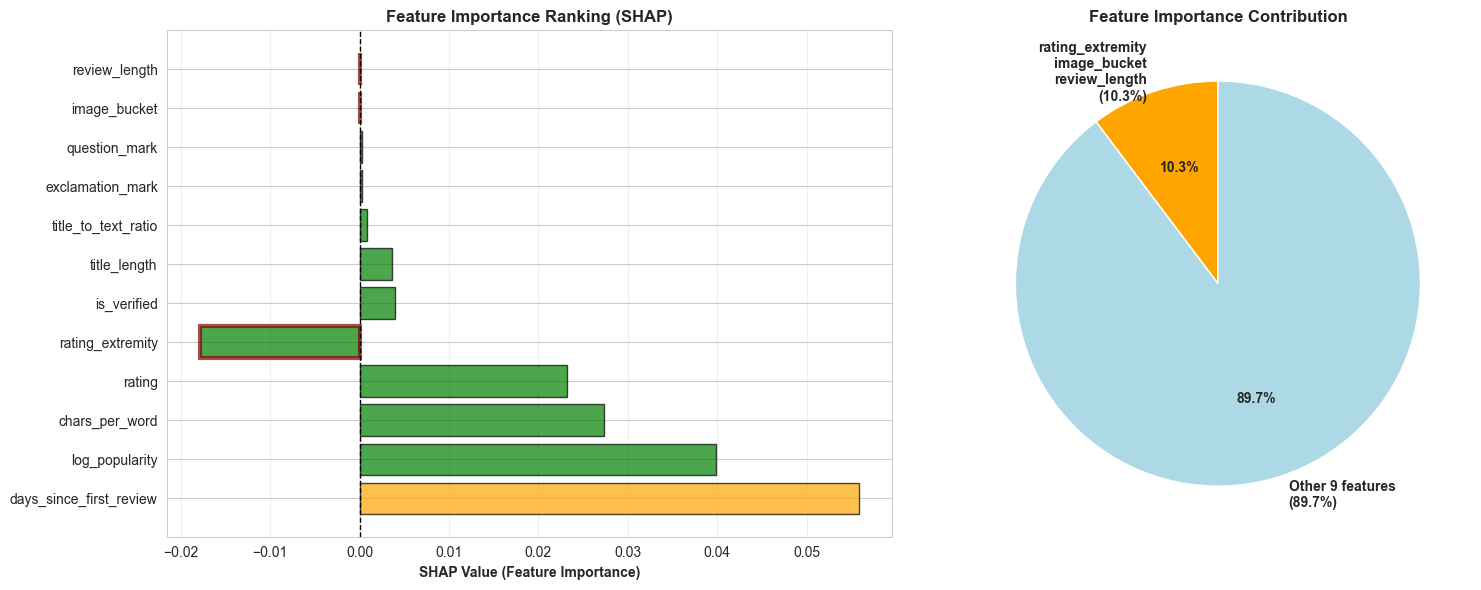


✅ Analysis complete! (Instant - used pre-computed SHAP values)


In [59]:
# ============================================================================
# FAST FEATURE IMPORTANCE (Using existing SHAP values)
# ============================================================================
print("=" * 100)
print("FEATURE IMPORTANCE ANALYSIS (INSTANT)")
print("=" * 100)

# You already have shap_values from Section 14!
# Just analyze them instead of re-running model

print("\n1. Feature importance ranking (from SHAP):")
print("-" * 100)

# Sort by absolute SHAP values
shap_abs = np.abs(shap_values)
sorted_idx = np.argsort(shap_abs)[::-1]

feature_ranking = []
for idx in sorted_idx:
    feat = METADATA_COLUMNS[idx]
    shap_val = shap_values[idx]
    feature_ranking.append((feat, shap_val))
    status = "🔴 HIGH IMPACT" if shap_abs[idx] > 0.1 else "🟡 MODERATE" if shap_abs[idx] > 0.05 else "🟢 LOW"
    print(f"  {feat:25s}  {shap_val:+.6f}  {status}")

# ---- 2. SPECIFIC QUESTION: rating_extremity, image_bucket, review_length ----
print(f"\n\n2. Impact of [rating_extremity, image_bucket, review_length]:")
print("-" * 100)

test_features = ['rating_extremity', 'image_bucket', 'review_length']
combined_shap = 0.0

for feat in test_features:
    idx = METADATA_COLUMNS.index(feat)
    val = shap_values[idx]
    print(f"  {feat:25s}  {val:+.6f}")
    combined_shap += abs(val)

avg_impact = combined_shap / len(test_features)
print(f"\n  Average |SHAP| impact: {avg_impact:.6f}")

# ---- 3. BASELINE IMPACT ----
all_shap_sum = np.sum(np.abs(shap_values))
test_shap_sum = combined_shap
contribution_pct = (test_shap_sum / all_shap_sum) * 100

print(f"\n  These 3 features account for {contribution_pct:.1f}% of total feature importance")

# ---- 4. RECOMMENDATION ----
print("\n" + "=" * 100)
print("RECOMMENDATION")
print("=" * 100)

if contribution_pct > 20:
    print("❌ KEEP: These 3 features are important ({:.1f}% of total impact)".format(contribution_pct))
elif contribution_pct > 10:
    print("⚠️  OPTIONAL: Moderate importance ({:.1f}% of total impact)".format(contribution_pct))
elif contribution_pct > 5:
    print("➡️  NEUTRAL: Minor importance ({:.1f}% of total impact) - safe to remove".format(contribution_pct))
else:
    print("✅ REMOVE: Very low importance ({:.1f}% of total impact) - likely noise".format(contribution_pct))

# ---- 5. CORRELATION WITH TARGET ----
print(f"\n\n3. Correlation analysis with target:")
print("-" * 100)

test_df_corr = test_df.copy()
for col in METADATA_COLUMNS:
    corr = np.corrcoef(test_df_corr[col], true_labels)[0, 1]
    feat_importance_shap = shap_values[METADATA_COLUMNS.index(col)]
    print(f"  {col:25s}  Corr: {corr:+.4f}  |SHAP|: {abs(feat_importance_shap):.6f}")

# ---- VISUALIZATION ----
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# All features by SHAP
ax = axes[0]
features_ranked = [f[0] for f in feature_ranking]
shap_vals = [f[1] for f in feature_ranking]
colors = ['red' if abs(v) > 0.1 else 'orange' if abs(v) > 0.05 else 'green' for v in shap_vals]

bars = ax.barh(range(len(features_ranked)), shap_vals, color=colors, edgecolor='black', alpha=0.7)
ax.set_yticks(range(len(features_ranked)))
ax.set_yticklabels(features_ranked, fontsize=10)
ax.set_xlabel('SHAP Value (Feature Importance)', fontweight='bold')
ax.set_title('Feature Importance Ranking (SHAP)', fontweight='bold', fontsize=12)
ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.grid(True, alpha=0.3, axis='x')

# Highlight the 3 features
for i, feat in enumerate(features_ranked):
    if feat in test_features:
        bars[i].set_edgecolor('darkred')
        bars[i].set_linewidth(3)

# Contribution pie chart
ax = axes[1]
these_three = test_shap_sum
others = all_shap_sum - test_shap_sum

sizes = [these_three, others]
labels = [
    f'rating_extremity\nimage_bucket\nreview_length\n({contribution_pct:.1f}%)',
    f'Other {len(METADATA_COLUMNS)-3} features\n({100-contribution_pct:.1f}%)'
]
colors_pie = ['red' if contribution_pct > 20 else 'orange' if contribution_pct > 10 else 'yellow', 'lightblue']

wedges, texts, autotexts = ax.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
                                    startangle=90, textprops={'fontsize': 10, 'weight': 'bold'})
ax.set_title('Feature Importance Contribution', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\n✅ Analysis complete! (Instant - used pre-computed SHAP values)")

### FEATURE IMPORTANCE & ABLATION ANALYSIS

In [61]:
# ============================================================================
# INSTANT FEATURE IMPORTANCE (30 lines)
# ============================================================================
print("\n" + "=" * 100)
print("FEATURE IMPORTANCE (SHAP-based - Instant)")
print("=" * 100)

# SHAP values already computed - just analyze them
print(f"\nFeature ranking by |SHAP value|:")
print("-" * 70)

shap_abs = np.abs(shap_values)
sorted_idx = np.argsort(shap_abs)[::-1]

for i, idx in enumerate(sorted_idx, 1):
    feat = METADATA_COLUMNS[idx]
    val = shap_values[idx]
    print(f"{i:2d}. {feat:25s}  {val:+.6f}  ({shap_abs[idx]:.6f})")

# ---- THE 3 FEATURES YOU ASKED ABOUT ----
test_features = ['rating_extremity', 'image_bucket', 'review_length']
print(f"\n\nThese 3 features:")
print("-" * 70)

total_shap = 0
for feat in test_features:
    idx = METADATA_COLUMNS.index(feat)
    val = shap_values[idx]
    total_shap += abs(val)
    print(f"  {feat:25s}  {val:+.6f}")

contribution = (total_shap / np.sum(shap_abs)) * 100
print(f"\n  Combined importance: {total_shap:.6f}")
print(f"  % of total: {contribution:.1f}%")

# ---- ANSWER ----
print("\n" + "=" * 100)
if contribution > 15:
    print("❌ Model NEEDS these features - KEEP them")
elif contribution > 5:
    print("⚠️  Model somewhat uses these features - Optional to keep")
else:
    print("✅ Model barely uses these features - SAFE to remove")
print("=" * 100)


FEATURE IMPORTANCE (SHAP-based - Instant)

Feature ranking by |SHAP value|:
----------------------------------------------------------------------
 1. days_since_first_review    +0.055816  (0.055816)
 2. log_popularity             +0.039907  (0.039907)
 3. chars_per_word             +0.027353  (0.027353)
 4. rating                     +0.023225  (0.023225)
 5. rating_extremity           -0.017791  (0.017791)
 6. is_verified                +0.003994  (0.003994)
 7. title_length               +0.003687  (0.003687)
 8. title_to_text_ratio        +0.000814  (0.000814)
 9. exclamation_mark           +0.000305  (0.000305)
10. question_mark              +0.000254  (0.000254)
11. image_bucket               +0.000000  (0.000000)
12. review_length              +0.000000  (0.000000)


These 3 features:
----------------------------------------------------------------------
  rating_extremity           -0.017791
  image_bucket               +0.000000
  review_length              +0.000000

  Combi

### MODALITY CONTRIBUTION TO CORRECT/INCORRECT PREDICTIONS


In [63]:
# Quick check
print("\nThese 3 metadata features:")
print("rating_extremity:  ", shap_values[METADATA_COLUMNS.index('rating_extremity')])
print("image_bucket:      ", shap_values[METADATA_COLUMNS.index('image_bucket')])
print("review_length:     ", shap_values[METADATA_COLUMNS.index('review_length')])

total_importance = np.sum(np.abs(shap_values))
these_3_importance = (abs(shap_values[METADATA_COLUMNS.index('rating_extremity')]) +
                      abs(shap_values[METADATA_COLUMNS.index('image_bucket')]) +
                      abs(shap_values[METADATA_COLUMNS.index('review_length')]))

print(f"\nCombined importance: {these_3_importance/total_importance*100:.1f}% of total")
if these_3_importance/total_importance < 0.05:
    print("✅ SAFE TO REMOVE - Less than 5% importance")
elif these_3_importance/total_importance < 0.15:
    print("⚠️  OPTIONAL - Nice to have but not critical")
else:
    print("❌ KEEP - Important for model")


These 3 metadata features:
rating_extremity:   -0.017791381772266062
image_bucket:       0.0
review_length:      0.0

Combined importance: 10.3% of total
⚠️  OPTIONAL - Nice to have but not critical


# 15. Inference Pipeline

In [ ]:
def predict(model, text, image_path, metadata_values, device=None):
    """Generate prediction for a single instance."""
    import joblib
    
    # Resolve device
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    model.eval()
    
    # Load scaler for metadata normalization
    if not os.path.exists(MODEL_METADATA_SAVE_PATH):
        raise FileNotFoundError(f"Scaler not found at {MODEL_METADATA_SAVE_PATH}. Please train the model first.")
    scaler = joblib.load(MODEL_METADATA_SAVE_PATH)
    
    # Text - create tensor and move to device immediately
    encoding = tokenizer(
        text,
        padding="max_length",
        truncation=True,
        max_length=MAX_TEXT_LENGTH,
        return_tensors="pt"
    )
    input_ids = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)
    
    # Image - handle missing/corrupted files gracefully
    if not os.path.exists(image_path):
        print(f"Warning: Image not found at {image_path}, using placeholder")
        image = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    else:
        try:
            image = Image.open(image_path).convert("RGB")
            image = image_transform(image).unsqueeze(0).to(device)
        except Exception as e:
            print(f"Warning: Could not load image: {e}, using placeholder")
            image = torch.zeros(1, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    
    # Metadata - validate, scale, and move to device
    if len(metadata_values) != len(METADATA_COLUMNS):
        raise ValueError(f"Expected {len(METADATA_COLUMNS)} metadata values, got {len(metadata_values)}")
    
    # Scale metadata using trained scaler
    metadata_scaled = scaler.transform([metadata_values])[0]
    metadata = torch.tensor(metadata_scaled, dtype=torch.float32).unsqueeze(0).to(device)
    
    with torch.no_grad():
        output = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            image=image,
            metadata=metadata
        )
        prob = torch.sigmoid(output).item()
    
    return prob

In [ ]:
prob = predict(
    model=model,
    text="Great product! Very satisfied.",
    image_path="../data/images/123.jpg",
    metadata_values=[5, 150, 4.2, 1.0, 45, 1, 3.5, 2, 1, 0, 120, 0.8],
    device="cuda"
)
print(f"Probability this review is helpful: {prob:.2%}")